# Task 04-01 &nbsp;|&nbsp; Baseline CNN, rebuilt for methodological review

**ResNet-18 on LIDC-IDRI, patient-level 5-fold cross-validation.** Reports accuracy, AUROC and
sensitivity at fixed specificity.

This replaces Task 04. The previous run reported AUROC 0.9005 and sensitivity 0.8508, and the
review was right that those numbers do not by themselves establish validity - the validity depends
on *how* they were produced. This notebook is reorganised so that each of those questions is
answered by **evidence printed in the notebook**, not by assertion.

| Review question | Where it is answered | Verdict |
|---|---|---|
| Were the patient-level folds genuinely separated? | §4 audit A1 | Previously correct - now **proven** per fold |
| Was preprocessing fitted only on training folds? | §5 audit A2 | Previously correct - now **enumerated and asserted** |
| Did multiple nodules from one patient stay in one fold? | §4 audit A1 | Previously correct - now **shown per patient** |
| How was the 48 mm physical patch extracted? | §3 + audit A3 | Documented; **overflow measured** |
| Is the 3-slice input centred consistently on the nodule? | §3 + audit A3 | **NO - this was a real bug. Fixed.** |
| How were malignancy labels constructed? | §2 + audit A4 | Documented; **each rule's effect counted** |
| Did model selection use test/OOF predictions? | §6 audit A5 | Previously correct - now **stated and asserted** |
| Do the CIs account for patient clustering? | §7 audit A6 | Previously correct - now **quantified against the naive CI** |

## The one substantive defect found

The in-plane crop was correctly sized in millimetres, but the two neighbouring slices making up the
2.5D input were taken at **&plusmn;1 slice index**, not a fixed physical distance. LIDC slice
thickness ranges roughly 0.6-5.0 mm, so the through-plane context varied by up to ~8&times; between
patients - and thickness is a property of the acquisition protocol, which varies by institution.
The network could therefore pick up scanner configuration rather than anatomy, in exactly the
dimension nobody was checking.

Section 3 now selects neighbours at a **fixed millimetre offset** and records, per nodule, the
offset actually achieved, so the remaining discrepancy is visible rather than assumed.

Fixing this changes the pixels, so the cache must be rebuilt and the model retrained. That is the
reason this is a new notebook rather than an edit.

## What else changed

- **False-negative analysis (§8).** 27 of 181 malignant nodules were missed. A single FNR hides
  whether those were borderline or obvious cases; the breakdown is now reported.
- **Sensitivity analyses (§9).** Two robustness checks a reviewer will otherwise ask for.
- **Honest denominators.** Every table states n = the number actually evaluated. No extrapolation.
- **Minimal outputs.** The previous run wrote 15 files with overlapping content. This one writes
  four, plus the fold checkpoints that Task 6 needs.

## 1 &nbsp;Configuration

Everything that defines the protocol lives here, and the values that must match across notebooks are
hashed into a dataset fingerprint (§4). Nothing below this cell hardcodes a number that belongs here.

`BUILD_VERSION` is new: it is written into the cache so a notebook can tell whether a cache it has
been handed was built with the corrected through-plane geometry or the old index-based one. Without
it, an old cache would load silently and reintroduce the bug.

In [1]:
import os, sys, json, math, time, random, warnings, glob, zipfile, shutil, hashlib
from pathlib import Path
warnings.filterwarnings("ignore")

BUILD_VERSION = "2.0-mm-throughplane"   # 1.x = old index-based neighbour slices (do not use)

CFG = dict(
    SEED = 42,
    MODEL = "resnet18",
    PRETRAINED = True,

    # ---------- data source ----------
    DATA_SOURCE = "auto",               # auto | cache | lidc_raw | phantom
    CACHE_NAME  = "lidc_nodules_cache_v2.npz",
    # A cache built by an older version has the old through-plane geometry. "auto" skips such a
    # cache and rebuilds. Set True only to deliberately re-run on the old data for comparison -
    # results are then NOT the corrected pipeline.
    ALLOW_OLD_CACHE = False,
    WORK        = "/kaggle/working",
    RAW_DIR     = "/kaggle/temp/lidc_raw",
    XML_DIR     = "/kaggle/temp/lidc_xml",

    # ---------- nodule extraction (PROTOCOL - hashed into the fingerprint) ----------
    N_PATIENTS   = 300,
    MIN_READERS  = 3,        # nodule must be marked by >= this many of the 4 radiologists
    DROP_SCORE_3 = True,     # median malignancy exactly 3 -> indeterminate -> excluded
    MATCH_MM     = 6.0,      # cross-reader nodule matching radius
    PATCH_MM     = 48.0,     # in-plane crop: 48mm x 48mm of anatomy, then resampled
    IMG_SIZE     = 224,
    N_SLICES     = 3,        # 2.5D context
    SLICE_MM     = 2.5,      # THE FIX: neighbour slices at +/- this many mm, not +/- 1 index
    HU_WINDOW    = (-1000.0, 400.0),

    # ---------- patient-level cross-validation ----------
    N_FOLDS = 5,
    VAL_FRAC_OF_TRAIN = 0.15,

    # ---------- training (fixed a priori - see audit A5) ----------
    EPOCHS = 30, BATCH_SIZE = 32, LR = 3e-4, WEIGHT_DECAY = 1e-4,
    DROPOUT_P = 0.30, DROPOUT_MODE = "head_and_stages",
    PATIENCE = 7, AMP = True, NUM_WORKERS = 2, CLASS_WEIGHTS = True,
    ALLOW_CPU_FALLBACK = True,

    # ---------- evaluation ----------
    TARGET_SPECIFICITIES = [0.90, 0.95, 0.99],
    TARGET_SENSITIVITY = 0.95,   # for the validation-selected clinical operating point (§7)
    N_BOOTSTRAP = 1000,
    N_ECE_BINS = 15,
)

CFG["OUT_DIR"]    = f"{CFG['WORK']}/task04_01_outputs"
CFG["CACHE_PATH"] = f"{CFG['WORK']}/{CFG['CACHE_NAME']}"
Path(CFG["OUT_DIR"]).mkdir(parents=True, exist_ok=True)

CLASS_NAMES = ["benign", "malignant"]
IS_SMOKE = False

# Only these affect which nodules exist and how they are split. Two runs that agree on all of them
# (and on the cache) are comparable with paired statistics; two that do not, are not.
PROTOCOL_KEYS = ["SEED", "N_PATIENTS", "MIN_READERS", "DROP_SCORE_3", "MATCH_MM", "PATCH_MM",
                 "IMG_SIZE", "N_SLICES", "SLICE_MM", "HU_WINDOW", "N_FOLDS", "VAL_FRAC_OF_TRAIN"]

print(f"Task 04-01  |  build {BUILD_VERSION}  |  model {CFG['MODEL']}")
print(json.dumps({k: CFG[k] for k in PROTOCOL_KEYS}, indent=2, default=str))

Task 04-01  |  build 2.0-mm-throughplane  |  model resnet18
{
  "SEED": 42,
  "N_PATIENTS": 300,
  "MIN_READERS": 3,
  "DROP_SCORE_3": true,
  "MATCH_MM": 6.0,
  "PATCH_MM": 48.0,
  "IMG_SIZE": 224,
  "N_SLICES": 3,
  "SLICE_MM": 2.5,
  "HU_WINDOW": [
    -1000.0,
    400.0
  ],
  "N_FOLDS": 5,
  "VAL_FRAC_OF_TRAIN": 0.15
}


### 1.1 &nbsp;Environment and GPU preflight

A PyTorch wheel only contains kernels for the GPU architectures it was compiled for. Kaggle's P100
is `sm_60`, which recent CUDA 12.x builds no longer ship - every CUDA call then fails, but only when
first made, which is deep inside training. The convolution below proves the device works before
anything expensive starts. With `ALLOW_CPU_FALLBACK` the run continues on CPU instead of stopping;
at this dataset size CPU is about 51 minutes for five folds, which is slow but perfectly usable.

In [2]:
import numpy as np, pandas as pd, torch, torch.nn as nn, matplotlib.pyplot as plt

def set_seed(seed):
    random.seed(seed); np.random.seed(seed)
    torch.manual_seed(seed); torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.benchmark = True

set_seed(CFG["SEED"])
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("torch", torch.__version__, "| numpy", np.__version__)

def gpu_preflight():
    """Prove the GPU can run a convolution before the expensive work begins."""
    global DEVICE
    if not torch.cuda.is_available():
        print("No accelerator attached - running on CPU (~51 min for 5 folds at this size).")
        print("For a GPU: Session options -> Accelerator -> GPU T4 x2  (not P100).")
        return False
    name = torch.cuda.get_device_name(0)
    cap = torch.cuda.get_device_capability(0)
    mine, built = f"sm_{cap[0]}{cap[1]}", [a for a in torch.cuda.get_arch_list()
                                           if a.startswith("sm_")]
    print(f"GPU {name} ({mine}) | torch built for {', '.join(built)}")
    try:
        torch.nn.functional.conv2d(torch.zeros(1, 3, 8, 8, device="cuda"),
                                   torch.zeros(4, 3, 3, 3, device="cuda"))
        torch.cuda.synchronize()
        print("preflight OK - a real convolution ran on the device")
        return True
    except Exception as e:
        msg = (f"\n{'='*70}\nTHIS GPU CANNOT RUN THIS PYTORCH BUILD\n{'='*70}\n"
               f"  {name} is {mine}; this wheel has {', '.join(built)}\n"
               f"  {type(e).__name__}: {e}\n"
               f"  FIX: Session options -> Accelerator -> 'GPU T4 x2' (sm_75)\n{'='*70}")
        print(msg)
        if CFG["ALLOW_CPU_FALLBACK"]:
            DEVICE = torch.device("cpu")
            print("  ALLOW_CPU_FALLBACK is on - continuing on CPU.")
            return False
        raise RuntimeError(msg) from e

GPU_OK = gpu_preflight()
print("device:", DEVICE)

torch 2.10.0+cu128 | numpy 2.0.2
GPU Tesla T4 (sm_75) | torch built for sm_70, sm_75, sm_80, sm_86, sm_90, sm_100, sm_120
preflight OK - a real convolution ran on the device
device: cuda


## 2 &nbsp;How the malignancy label is constructed

LIDC-IDRI has no label column. Up to four radiologists independently outlined each nodule and scored
it 1-5 for malignancy (1 = highly unlikely, 5 = highly suspicious). Producing a binary label takes
three decisions, and results are only comparable between studies that made them the same way.

| Decision | Choice | Reasoning |
|---|---|---|
| Which nodules to keep | marked by **&ge; 3** of 4 readers | single-reader marks are noisy and inflate scores |
| How to fuse the ratings | **median** | robust to one dissenting reader; the dominant convention |
| Median exactly 3 | **excluded** | indeterminate is neither class; keeping it corrupts both |

Label: median &lt; 3 &rarr; benign, median &gt; 3 &rarr; malignant.

**A consequence worth stating plainly.** With four readers the median can be 2.5 or 3.5. Those
nodules are one reader away from the exclusion rule, and in the previous run they were 115 of 322
(36%) of the dataset. They are kept - dropping them is not the convention - but §9 reports what
happens if they are removed, because a reviewer will ask whether the result rests on them.

The other eight characteristics (spiculation, margin, subtlety, lobulation, calcification, texture,
sphericity, internal structure) are cached too: they are needed for the false-negative analysis in
§8 and for Task 8's concept-based explainability.

### Matching one nodule across four readers

The readers worked blind to each other, so reader 1's "nodule 3" and reader 4's "nodule 1" may be
the same lesion. They are grouped by centroid proximity in millimetres before the ratings are
fused, with one constraint a plain nearest-neighbour pass gets wrong: **a cluster may contain at
most one nodule per reader.** Without it, two distinct lesions that one reader marked close together
merge into a single cluster, its reader count becomes meaningless, and the &ge;3-reader filter
silently stops working.

In [3]:
import xml.etree.ElementTree as ET
from collections import defaultdict

def _tag(e):
    """LIDC XML namespaces vary between files - compare on the local name only."""
    return e.tag.split("}")[-1]

CHARACTERISTIC_KEYS = ["subtlety", "internalStructure", "calcification", "sphericity",
                       "margin", "lobulation", "spiculation", "texture", "malignancy"]

def parse_lidc_xml(xml_path):
    """One LIDC XML -> (series_uid, [per-reader nodule lists]).

    Nodules without a <characteristics> block are the <3mm marks: they carry no malignancy
    rating, so they cannot be labelled and are dropped here.
    """
    root = ET.parse(xml_path).getroot()
    series_uid = None
    for e in root.iter():
        if _tag(e) in ("SeriesInstanceUid", "SeriesInstanceUID"):
            series_uid = (e.text or "").strip(); break

    sessions = []
    for sess in root.iter():
        if _tag(sess) != "readingSession":
            continue
        nodules = []
        for nod in sess:
            if _tag(nod) != "unblindedReadNodule":
                continue
            chars, rois = {}, []
            for child in nod:
                t = _tag(child)
                if t == "characteristics":
                    for c in child:
                        try:
                            chars[_tag(c)] = int(float((c.text or "").strip()))
                        except (TypeError, ValueError):
                            pass
                elif t == "roi":
                    z, pts, included = None, [], True
                    for r in child:
                        rt = _tag(r)
                        if rt == "imageZposition":
                            z = float(r.text)
                        elif rt == "inclusion":
                            included = (r.text or "").strip().upper() == "TRUE"
                        elif rt == "edgeMap":
                            x = y = None
                            for e2 in r:
                                if _tag(e2) == "xCoord":   x = int(float(e2.text))
                                elif _tag(e2) == "yCoord": y = int(float(e2.text))
                            if x is not None and y is not None:
                                pts.append((x, y))
                    if pts and included:
                        rois.append(dict(z=z, pts=np.asarray(pts, dtype=np.float32)))
            if rois and "malignancy" in chars:
                nodules.append(dict(characteristics=chars, rois=rois))
        sessions.append(nodules)
    return series_uid, sessions


def nodule_geometry(nodule):
    """Centroid (col, row, z_mm) plus in-plane extents in pixels.

    Returns the bounding-box width and height separately rather than a single "diameter":
    the previous run reported the box DIAGONAL as diam_mm, which overstates a round nodule's
    size by a factor of ~1.41 and made patch-overflow look worse than it is.
    """
    pts = np.concatenate([r["pts"] for r in nodule["rois"]], axis=0)
    zs = [r["z"] for r in nodule["rois"] if r["z"] is not None]
    w = h = 0.0
    for r in nodule["rois"]:
        p = r["pts"]
        if len(p) > 1:
            w = max(w, float(np.ptp(p[:, 0]))); h = max(h, float(np.ptp(p[:, 1])))
    return (float(pts[:, 0].mean()), float(pts[:, 1].mean()),
            float(np.mean(zs)) if zs else None, w, h)


def cluster_nodules_across_readers(sessions, spacing_xy, match_mm):
    """Group per-reader marks into physical lesions, at most one mark per reader per cluster."""
    items = []
    for r_idx, nodules in enumerate(sessions):
        for nod in nodules:
            cx, cy, cz, w, h = nodule_geometry(nod)
            if cz is None:
                continue
            items.append(dict(reader=r_idx, nodule=nod, cx=cx, cy=cy, cz=cz, w=w, h=h))

    items.sort(key=lambda d: (d["cz"], d["cx"], d["cy"], d["reader"]))   # deterministic
    sx, sy = spacing_xy
    clusters = []
    for it in items:
        best, best_d = None, np.inf
        for cl in clusters:
            if any(m["reader"] == it["reader"] for m in cl):
                continue                                   # reader already represented
            d = math.sqrt(((it["cx"] - np.mean([m["cx"] for m in cl])) * sx) ** 2 +
                          ((it["cy"] - np.mean([m["cy"] for m in cl])) * sy) ** 2 +
                          (it["cz"] - np.mean([m["cz"] for m in cl])) ** 2)
            if d < best_d:
                best, best_d = cl, d
        if best is not None and best_d <= match_mm:
            best.append(it)
        else:
            clusters.append([it])
    return clusters


def fuse_cluster_labels(cluster, min_readers, drop_score_3):
    """Cluster -> one labelled nodule, or None if it fails the protocol."""
    readers = {m["reader"] for m in cluster}
    if len(readers) < min_readers:
        return None
    scores = defaultdict(list)
    for m in cluster:
        for k in CHARACTERISTIC_KEYS:
            if k in m["nodule"]["characteristics"]:
                scores[k].append(m["nodule"]["characteristics"][k])
    if not scores.get("malignancy"):
        return None

    mal = float(np.median(scores["malignancy"]))
    if drop_score_3 and abs(mal - 3.0) < 1e-9:
        return None

    return dict(
        n_readers=len(readers), malignancy=mal, label=int(mal > 3.0),
        # spread of the 3-4 human ratings: measured ambiguity, used in the FN analysis and Task 6
        mal_std=float(np.std(scores["malignancy"])),
        cx=float(np.mean([m["cx"] for m in cluster])),
        cy=float(np.mean([m["cy"] for m in cluster])),
        cz=float(np.mean([m["cz"] for m in cluster])),
        bbox_w_px=float(np.mean([m["w"] for m in cluster])),
        bbox_h_px=float(np.mean([m["h"] for m in cluster])),
        **{f"c_{k}": float(np.median(v)) for k, v in scores.items()},
    )

## 3 &nbsp;Patch extraction &mdash; and the through-plane fix

This is where the review question "*is the 3-slice input centred consistently on the nodule?*" is
answered, and where the previous implementation was wrong.

### In-plane: correct before, unchanged

The crop is **48 mm &times; 48 mm of anatomy**, converted to pixels per scan using that scan's
`PixelSpacing`, then resampled to 224 &times; 224. Pixel spacing across LIDC varies roughly
0.5-0.9 mm, so a fixed *pixel* crop would contain ~40% more tissue on one scan than another and the
network would partly learn scanner configuration. Sizing in millimetres removes that.

Padding is applied **before** cropping, so a nodule against the chest wall still yields a full-size
patch with the nodule at the centre. Cropping first and padding after would shift it off-centre.

### Through-plane: this was the bug

The two neighbouring slices were taken at **&plusmn;1 slice index**. Slice thickness in LIDC ranges
roughly 0.6-5.0 mm, so:

| Scan thickness | Old context window | What the 3 channels actually held |
|---|---|---|
| 0.6 mm | &plusmn;0.6 mm | three near-identical slices |
| 2.5 mm | &plusmn;2.5 mm | the intended 2.5D context |
| 5.0 mm | &plusmn;5.0 mm | three quite different levels |

So the amount of through-plane context was a function of the acquisition protocol, which varies by
institution and scanner - a confound sitting in the one dimension nobody was auditing.

**The fix:** neighbours are selected at a fixed physical offset (`SLICE_MM` = 2.5 mm) by finding the
nearest available slice to `z_centroid &plusmn; SLICE_MM`. On a thick-slice scan the nearest slice may
still be several mm away, and that residual cannot be removed without interpolating - so the
**achieved** offset is recorded per nodule and audited in A3, rather than assumed.

### Provenance recorded per nodule

The previous cache stored no acquisition geometry, so these questions could not be answered from it
at all. Each nodule now carries `spacing_x`, `spacing_y`, `slice_thickness`, the achieved
through-plane offsets, and whether the lesion overflowed the patch.

In [4]:
def load_ct_series(series_dir):
    """Read one DICOM CT series -> HU volume sorted along z, plus acquisition geometry."""
    import pydicom
    slices = []
    for p in glob.glob(os.path.join(series_dir, "**", "*.dcm"), recursive=True):
        try:
            ds = pydicom.dcmread(p, force=True)
            if hasattr(ds, "PixelData") and hasattr(ds, "ImagePositionPatient") \
                    and getattr(ds, "Modality", "CT") == "CT":
                slices.append(ds)
        except Exception:
            continue
    if len(slices) < 10:
        return None

    slices.sort(key=lambda d: float(d.ImagePositionPatient[2]))
    ref = slices[0]
    spacing = [float(v) for v in getattr(ref, "PixelSpacing", [1.0, 1.0])]
    vol = np.stack([s.pixel_array.astype(np.float32) for s in slices], axis=0)
    vol = vol * float(getattr(ref, "RescaleSlope", 1.0)) + float(getattr(ref, "RescaleIntercept", 0.0))
    vol[vol < -2000] = -1000.0          # out-of-field padding -> air

    z = np.array([float(s.ImagePositionPatient[2]) for s in slices])
    return dict(vol=vol, z_pos=z,
                spacing=(spacing[1], spacing[0]),                    # (x, y) mm/pixel
                thickness=float(getattr(ref, "SliceThickness", np.nan)),
                z_step=float(np.median(np.diff(z))) if len(z) > 1 else np.nan,
                patient_id=str(getattr(ref, "PatientID", "")),
                series_uid=str(getattr(ref, "SeriesInstanceUID", "")))


def extract_patch(series, nod, cfg):
    """Nodule -> (n_slices, IMG_SIZE, IMG_SIZE) uint8 patch + the geometry actually achieved.

    In-plane size and through-plane offsets are both specified in millimetres. The achieved
    offsets are returned because on a thick-slice scan the nearest slice to +/-SLICE_MM can be
    some way off, and that residual should be visible rather than silently absorbed.
    """
    import cv2
    vol, z_pos = series["vol"], series["z_pos"]
    sx, sy = series["spacing"]
    lo, hi = cfg["HU_WINDOW"]

    half_x = max(2, int(round((cfg["PATCH_MM"] / 2.0) / sx)))
    half_y = max(2, int(round((cfg["PATCH_MM"] / 2.0) / sy)))
    cx, cy = int(round(nod["cx"])), int(round(nod["cy"]))

    n = cfg["N_SLICES"]
    wanted = [0.0] if n == 1 else [(i - n // 2) * cfg["SLICE_MM"] for i in range(n)]

    out, achieved, chosen = [], [], []
    for off_mm in wanted:
        target = nod["cz"] + off_mm
        # Nearest slice to the target. On a regular grid the target often falls exactly halfway
        # between two slices; np.argmin would then always take the lower index, which makes the
        # context window lopsided (e.g. -3mm above but +2mm below the centroid). Break ties
        # toward the centroid so the sampling stays symmetric.
        d = np.abs(z_pos - target)
        cand = np.flatnonzero(d <= d.min() + 1e-9)
        zi = int(cand[np.argmin(np.abs(z_pos[cand] - nod["cz"]))])
        chosen.append(zi)
        achieved.append(float(z_pos[zi] - nod["cz"]))

        # pad first so a peripheral nodule still lands in the centre of a full-size crop
        pad_y, pad_x = half_y + 1, half_x + 1
        padded = np.pad(vol[zi], ((pad_y, pad_y), (pad_x, pad_x)),
                        mode="constant", constant_values=lo)
        crop = padded[cy + pad_y - half_y: cy + pad_y + half_y,
                      cx + pad_x - half_x: cx + pad_x + half_x]
        if crop.size == 0:
            return None, None
        win = ((np.clip(crop, lo, hi) - lo) / (hi - lo) * 255.0).astype(np.uint8)
        out.append(cv2.resize(win, (cfg["IMG_SIZE"],) * 2, interpolation=cv2.INTER_LINEAR))

    geom = dict(spacing_x=sx, spacing_y=sy,
                slice_thickness=series["thickness"], z_step=series["z_step"],
                offset_wanted_mm=json.dumps([round(v, 3) for v in wanted]),
                offset_achieved_mm=json.dumps([round(v, 3) for v in achieved]),
                offset_error_mm=float(np.max(np.abs(np.array(achieved) - np.array(wanted)))),
                # On a thick-slice scan no slice may exist near +/-SLICE_MM, so the three
                # channels can collapse to the same image. That is honest - the context simply
                # is not in the data - but it must be visible, not silent.
                n_distinct_slices=int(len(set(chosen))),
                nodule_w_mm=nod["bbox_w_px"] * sx, nodule_h_mm=nod["bbox_h_px"] * sy,
                overflows_patch=bool(max(nod["bbox_w_px"] * sx,
                                         nod["bbox_h_px"] * sy) > cfg["PATCH_MM"]))
    return np.stack(out, axis=0), geom

### 3.1 &nbsp;Downloading LIDC-IDRI

`tcia_utils` fetches the CT series. The nodule annotations are a **separate XML package** - the
original Task 3 run failed silently here, reporting `no annotations found`, because it downloaded
images only. If the XML cannot be fetched the cell raises with instructions rather than continuing
label-free.

In [5]:
def download_lidc_dicom(n_patients, out_dir):
    """One CT series per patient for the first n_patients, deterministically selected."""
    try:
        from tcia_utils import nbia
    except ImportError:
        get_ipython().system("pip install -q tcia_utils")
        from tcia_utils import nbia

    os.makedirs(out_dir, exist_ok=True)
    df = pd.DataFrame(nbia.getSeries(collection="LIDC-IDRI"))
    df = df[df["Modality"] == "CT"].copy()                  # LIDC also contains DX/CR
    df["ImageCount"] = pd.to_numeric(df["ImageCount"], errors="coerce").fillna(0)
    df = (df.sort_values(["PatientID", "ImageCount"], ascending=[True, False])
            .groupby("PatientID", as_index=False).first().sort_values("PatientID"))
    sel = df.head(n_patients)
    print(f"LIDC-IDRI: {df.PatientID.nunique()} patients with CT | selecting {len(sel)}")
    print(f"~{0.9 * sel.ImageCount.sum() / 1000:.1f} GB, {int(sel.ImageCount.sum())} slices")
    nbia.downloadSeries(sel.to_dict("records"), path=out_dir)
    return sel


LIDC_XML_URLS = [
    "https://www.cancerimagingarchive.net/wp-content/uploads/LIDC-XML-only.zip",
    "https://wiki.cancerimagingarchive.net/download/attachments/1966254/LIDC-XML-only.zip",
]

def download_lidc_xml(xml_dir):
    """Fetch + unzip the annotation package. Raises loudly rather than proceeding unlabelled."""
    import requests
    os.makedirs(xml_dir, exist_ok=True)
    if glob.glob(os.path.join(xml_dir, "**", "*.xml"), recursive=True):
        print("XML annotations already present."); return xml_dir

    zp = os.path.join(xml_dir, "LIDC-XML-only.zip")
    for url in LIDC_XML_URLS:
        try:
            print("Trying", url)
            with requests.get(url, stream=True, timeout=180) as r:
                r.raise_for_status()
                with open(zp, "wb") as f:
                    for chunk in r.iter_content(1 << 20):
                        f.write(chunk)
            with zipfile.ZipFile(zp) as z:
                z.extractall(xml_dir)
            os.remove(zp)
            print(f"Extracted {len(glob.glob(os.path.join(xml_dir,'**','*.xml'), recursive=True))} XMLs")
            return xml_dir
        except Exception as e:
            print("  failed:", type(e).__name__, e)

    raise RuntimeError(
        "Could not fetch the LIDC XML annotation package.\n"
        "MANUAL FIX (once): download 'LIDC-XML-only.zip' from the LIDC-IDRI page on "
        "cancerimagingarchive.net, upload it as a Kaggle Dataset, attach it, and set "
        "CFG['XML_DIR'] to that /kaggle/input path.\n"
        "Without these XMLs there are no malignancy labels and no supervised task.")


def index_xml_by_series(xml_dir):
    idx, files = {}, glob.glob(os.path.join(xml_dir, "**", "*.xml"), recursive=True)
    for p in files:
        try:
            uid, _ = parse_lidc_xml(p)
            if uid:
                idx[uid] = p
        except Exception:
            continue
    print(f"Indexed {len(idx)} / {len(files)} XMLs by SeriesInstanceUID")
    return idx

### 3.2 &nbsp;Building the cache

Run once. Save the resulting `.npz` as a Kaggle Dataset and every later run - Task 5, Task 6, any
re-run - attaches it and skips the download.

Rows are written in a **canonical order** (patient, then series, then nodule position) rather than
filesystem traversal order. The fold assignment is derived from row order, so without this two
machines could download identical data and still produce different folds.

In [6]:
def build_lidc_cache(cfg):
    """Raw LIDC -> labelled patch cache with full geometric provenance."""
    t0 = time.time()
    download_lidc_dicom(cfg["N_PATIENTS"], cfg["RAW_DIR"])
    xml_index = index_xml_by_series(download_lidc_xml(cfg["XML_DIR"]))

    patches, rows, stats = [], [], defaultdict(int)
    series_dirs = sorted(d for d in glob.glob(os.path.join(cfg["RAW_DIR"], "**"), recursive=True)
                         if os.path.isdir(d) and glob.glob(os.path.join(d, "*.dcm")))
    print(f"{len(series_dirs)} series directories with DICOM")

    for i, sdir in enumerate(series_dirs, 1):
        series = load_ct_series(sdir)
        if series is None:
            stats["series_unreadable"] += 1; continue
        suid = series["series_uid"] or os.path.basename(sdir)
        if suid not in xml_index:
            stats["series_no_annotation"] += 1; continue

        _, sessions = parse_lidc_xml(xml_index[suid])
        clusters = cluster_nodules_across_readers(sessions, series["spacing"], cfg["MATCH_MM"])
        stats["clusters_found"] += len(clusters)

        kept = 0
        for cl in clusters:
            nod = fuse_cluster_labels(cl, cfg["MIN_READERS"], cfg["DROP_SCORE_3"])
            if nod is None:
                stats["rejected_by_protocol"] += 1; continue
            patch, geom = extract_patch(series, nod, cfg)
            if patch is None:
                stats["patch_failed"] += 1; continue
            nod.update(geom, patient_id=series["patient_id"] or suid, series_uid=suid)
            patches.append(patch); rows.append(nod); kept += 1

        stats["series_used"] += 1
        if kept:
            print(f"  [{i}/{len(series_dirs)}] {series['patient_id']}: +{kept} "
                  f"(total {len(patches)})")
        del series                      # a 512x512x140 float32 volume is ~150 MB

    if not patches:
        raise RuntimeError(f"No nodules extracted. Diagnostics: {dict(stats)}")

    # canonical order - row order must depend on the data, not on disk layout
    order = sorted(range(len(rows)), key=lambda i: (
        str(rows[i]["patient_id"]), str(rows[i]["series_uid"]),
        round(rows[i]["cz"], 2), round(rows[i]["cy"], 2), round(rows[i]["cx"], 2)))
    patches = [patches[i] for i in order]; rows = [rows[i] for i in order]

    X, meta = np.stack(patches).astype(np.uint8), pd.DataFrame(rows)
    np.savez_compressed(
        cfg["CACHE_PATH"], patches=X,
        labels=meta["label"].to_numpy(np.int64),
        malignancy=meta["malignancy"].to_numpy(np.float32),
        patient_id=meta["patient_id"].to_numpy(object),
        meta_json=json.dumps(meta.to_dict("list"), default=str),
        cfg_json=json.dumps({**{k: cfg[k] for k in PROTOCOL_KEYS},
                             "BUILD_VERSION": BUILD_VERSION,
                             "diagnostics": dict(stats)}, default=str))

    print(f"\nBuilt in {(time.time()-t0)/60:.1f} min: {X.shape[0]} nodules from "
          f"{meta.patient_id.nunique()} patients -> {cfg['CACHE_PATH']} "
          f"({os.path.getsize(cfg['CACHE_PATH'])/1e6:.0f} MB)")
    print(f"diagnostics: {dict(stats)}")
    print(">>> Save a Version, then publish this .npz as a Kaggle Dataset.")
    return cfg["CACHE_PATH"]


def build_phantom_cache(cfg, n_patients=60, per_patient=6):
    """Synthetic stand-in so the pipeline stays runnable without LIDC. Results are NOT reportable."""
    import cv2
    rng = np.random.default_rng(cfg["SEED"]); S, K = cfg["IMG_SIZE"], cfg["N_SLICES"]
    X, rows = [], []
    for p in range(n_patients):
        for _ in range(per_patient):
            y = int(rng.random() < 0.45)
            base = cv2.GaussianBlur(rng.normal(.25, .06, (S, S)).astype(np.float32), (0, 0), 6)
            yy, xx = np.mgrid[0:S, 0:S].astype(np.float32)
            cxp, cyp = S / 2 + rng.normal(0, 4, 2); r = S * rng.uniform(.10, .20)
            th = np.arctan2(yy - cyp, xx - cxp)
            rr = r * (1 + (0.32 if y else 0.06) * np.sin(int(rng.integers(6, 12)) * th))
            blob = np.clip((rr - np.hypot(xx - cxp, yy - cyp)) / (.18 * r), 0, 1)
            img = np.clip(cv2.GaussianBlur(base + blob * rng.uniform(.45, .70), (0, 0), 1), 0, 1)
            X.append((np.stack([np.clip(img + rng.normal(0, .012, (S, S)), 0, 1)
                                for _ in range(K)]) * 255).astype(np.uint8))
            rows.append(dict(patient_id=f"PHANTOM-{p:04d}", series_uid=f"S{p}",
                             malignancy=float(rng.choice([4., 5.]) if y else rng.choice([1., 2.])),
                             label=y, n_readers=4, mal_std=float(rng.uniform(0, 1)),
                             cx=S/2, cy=S/2, cz=0.0, bbox_w_px=r, bbox_h_px=r,
                             spacing_x=0.7, spacing_y=0.7, slice_thickness=2.5, z_step=2.5,
                             offset_wanted_mm="[-2.5, 0.0, 2.5]",
                             offset_achieved_mm="[-2.5, 0.0, 2.5]", offset_error_mm=0.0,
                             n_distinct_slices=3,
                             nodule_w_mm=r*0.7, nodule_h_mm=r*0.7, overflows_patch=False,
                             **{f"c_{k}": 3.0 for k in CHARACTERISTIC_KEYS}))
    meta = pd.DataFrame(rows)
    np.savez_compressed(cfg["CACHE_PATH"], patches=np.stack(X),
                        labels=meta["label"].to_numpy(np.int64),
                        malignancy=meta["malignancy"].to_numpy(np.float32),
                        patient_id=meta["patient_id"].to_numpy(object),
                        meta_json=json.dumps(meta.to_dict("list"), default=str),
                        cfg_json=json.dumps({"PHANTOM": True,
                                             "BUILD_VERSION": BUILD_VERSION}))
    print(f"PHANTOM cache: {len(X)} patches / {n_patients} pseudo-patients")
    return cfg["CACHE_PATH"]


def cache_build_version(path):
    """Which builder produced this cache. Old caches predate the field entirely."""
    try:
        with np.load(path, allow_pickle=True) as z:
            if not {"patches", "labels", "patient_id"} <= set(z.files):
                return None
            cfg = json.loads(str(z["cfg_json"])) if "cfg_json" in z.files else {}
            return cfg.get("BUILD_VERSION", "1.x (pre-fix)")
    except Exception:
        return None


def find_input_cache(name, cfg):
    """Find an attached cache built by THIS version.

    The generic *.npz sweep is what makes attaching the wrong dataset easy, so version is checked
    before a cache is accepted rather than after it is loaded. A mismatched cache is named and
    skipped, so the reason for the rebuild is obvious in the log.
    """
    seen, usable = [], []
    for p in (glob.glob(f"/kaggle/input/**/{name}", recursive=True)
              + glob.glob("/kaggle/input/**/*.npz", recursive=True)):
        if p in [s for s, _ in seen]:
            continue
        v = cache_build_version(p)
        if v is None:
            continue                                   # not a nodule cache at all
        seen.append((p, v))
        if v == BUILD_VERSION or cfg.get("ALLOW_OLD_CACHE", False):
            usable.append((p, v))

    for p, v in seen:
        mark = "USABLE" if (p, v) in usable else "SKIPPED - wrong build version"
        print(f"  found cache {os.path.basename(p)}  build={v}  -> {mark}")

    if usable:
        p, v = usable[0]
        if v != BUILD_VERSION:
            print(f"  ALLOW_OLD_CACHE is on: using a '{v}' cache deliberately.")
        return p
    if seen:
        print(f"  No attached cache was built by '{BUILD_VERSION}'. Rebuilding from raw LIDC.")
        print(f"  (Set CFG['ALLOW_OLD_CACHE']=True to reuse the old one for comparison instead.)")
    return None


def resolve_data(cfg):
    global IS_SMOKE
    src = cfg["DATA_SOURCE"]
    if src in ("auto", "cache"):
        p = find_input_cache(cfg["CACHE_NAME"], cfg)
        if p is None and os.path.exists(cfg["CACHE_PATH"]):
            v = cache_build_version(cfg["CACHE_PATH"])
            if v == BUILD_VERSION or cfg.get("ALLOW_OLD_CACHE", False):
                p = cfg["CACHE_PATH"]
        if p:
            print("Using cache:", p); return p
        if src == "cache":
            raise FileNotFoundError(
                f"DATA_SOURCE='cache' but no cache built by '{BUILD_VERSION}' was found.\n"
                f"Either attach one, set DATA_SOURCE='lidc_raw' to build it, or set "
                f"CFG['ALLOW_OLD_CACHE']=True to reuse an older cache knowingly.")
    if src in ("auto", "lidc_raw"):
        try:
            return build_lidc_cache(cfg)
        except Exception as e:
            print(f"\n{'!'*70}\nRAW BUILD FAILED: {type(e).__name__}: {e}\n{'!'*70}")
            if src == "lidc_raw":
                raise
    print(f"\n{'='*70}\nFALLING BACK TO PHANTOM DATA - RESULTS NOT REPORTABLE\n{'='*70}")
    IS_SMOKE = True
    return build_phantom_cache(cfg)


CACHE = resolve_data(CFG)

  found cache lidc_nodules_cache_v2.npz  build=2.0-mm-throughplane  -> USABLE
  found cache lidc_nodules_cache.npz  build=1.x (pre-fix)  -> SKIPPED - wrong build version
Using cache: /kaggle/input/datasets/xainab123/lidc-nodules-cache-v2/lidc_nodules_cache_v2.npz


In [7]:
with np.load(CACHE, allow_pickle=True) as z:
    PATCHES    = z["patches"]
    LABELS     = z["labels"].astype(np.int64)
    MALIGNANCY = z["malignancy"].astype(np.float32)
    PATIENT_ID = np.asarray([str(v) for v in z["patient_id"]])
    BUILD_CFG  = json.loads(str(z["cfg_json"]))
    META       = pd.DataFrame(json.loads(str(z["meta_json"])))

IS_SMOKE = IS_SMOKE or bool(BUILD_CFG.get("PHANTOM", False))
CACHE_BUILD = BUILD_CFG.get("BUILD_VERSION", "1.x (pre-fix)")

print(f"patches {PATCHES.shape} {PATCHES.dtype} | {len(LABELS)} nodules, "
      f"{len(np.unique(PATIENT_ID))} patients")
print(f"benign {int((LABELS==0).sum())} | malignant {int((LABELS==1).sum())} "
      f"({100*LABELS.mean():.1f}% positive)")
print(f"cache build version: {CACHE_BUILD}")
print(f"SMOKE: {IS_SMOKE}")

# The whole point of this notebook is the corrected through-plane geometry. An old cache would
# load without complaint and silently reintroduce the defect, so refuse to be quiet about it.
HAS_GEOMETRY = "offset_error_mm" in META.columns
if CACHE_BUILD != BUILD_VERSION:
    print(f"\n{'!'*74}")
    print(f"WARNING: this cache was built by version '{CACHE_BUILD}', not '{BUILD_VERSION}'.")
    print(f"(You are seeing this because ALLOW_OLD_CACHE is on, or the cache was in the working")
    print(f"directory. Otherwise the resolver would have rebuilt instead.)")
    print("Its neighbour slices were taken at +/-1 slice INDEX, so the 2.5D context is not")
    print("physically consistent across scans - the defect this notebook exists to fix.")
    print("Results below are still internally valid, but do NOT present them as the corrected")
    print("pipeline. Rebuild with DATA_SOURCE='lidc_raw' for that.")
    print(f"{'!'*74}")

patches (322, 3, 224, 224) uint8 | 322 nodules, 187 patients
benign 141 | malignant 181 (56.2% positive)
cache build version: 2.0-mm-throughplane
SMOKE: False


### Audit A3 &nbsp;|&nbsp; Patch geometry

Evidence for "*how was the 48 mm patch extracted*" and "*is the 3-slice input centred consistently*".

- **In-plane**: the pixel-spacing spread shows how much a fixed-pixel crop would have varied.
- **Through-plane**: `offset_error_mm` is how far the chosen neighbour slice actually sat from the
  requested &plusmn;2.5 mm. Zero means exact; large values mean a thick-slice scan where no closer
  slice exists. This residual is a property of the data, not of the code, and is reported rather
  than hidden.
- **Overflow**: nodules whose in-plane extent exceeds 48 mm are clipped. LIDC's inclusion criterion
  is 3-30 mm so this should be rare; the count is reported so "rare" is a number.

In [8]:
if not HAS_GEOMETRY:
    print("This cache predates geometric provenance (v1.x) - audit A3 cannot be run on it.\n"
          "The v1.x builder recorded no spacing or thickness, which is itself part of why\n"
          "the review's question could not be answered from the previous artefacts.")
else:
    g = META
    print("IN-PLANE pixel spacing (mm/px)")
    print(f"  x: min {g.spacing_x.min():.3f}  max {g.spacing_x.max():.3f}  "
          f"median {g.spacing_x.median():.3f}")
    print(f"  a fixed-pixel crop would have spanned "
          f"{g.spacing_x.min()*CFG['IMG_SIZE']:.0f}-{g.spacing_x.max()*CFG['IMG_SIZE']:.0f} mm "
          f"of anatomy; the mm-based crop spans {CFG['PATCH_MM']:.0f} mm for every nodule.")

    print("\nTHROUGH-PLANE")
    print(f"  slice thickness: min {g.slice_thickness.min():.2f}  max "
          f"{g.slice_thickness.max():.2f}  median {g.slice_thickness.median():.2f} mm")
    print(f"  requested neighbour offset: +/-{CFG['SLICE_MM']} mm")
    print(f"  achieved offset error: median {g.offset_error_mm.median():.2f}  "
          f"p95 {g.offset_error_mm.quantile(.95):.2f}  max {g.offset_error_mm.max():.2f} mm")
    bad = int((g.offset_error_mm > CFG["SLICE_MM"]).sum())
    print(f"  nodules where no slice exists within {CFG['SLICE_MM']} mm of the target: "
          f"{bad} ({100*bad/len(g):.1f}%)  <- thick-slice scans, irreducible without interpolation")
    if "n_distinct_slices" in g.columns:
        deg = int((g.n_distinct_slices < CFG["N_SLICES"]).sum())
        print(f"  nodules whose {CFG['N_SLICES']} channels collapse to fewer distinct slices: "
              f"{deg} ({100*deg/len(g):.1f}%)")
        print(f"    on those, the 2.5D input carries no real through-plane context. The context")
        print(f"    is absent from the acquisition, not discarded by the code - but if this "
              f"fraction")
        print(f"    is large, report it as a dataset limitation rather than leaving it implicit.")
    print(f"  under the OLD +/-1-index rule the context window would have been "
          f"+/-{g.slice_thickness.min():.1f} to +/-{g.slice_thickness.max():.1f} mm "
          f"({g.slice_thickness.max()/max(g.slice_thickness.min(),1e-6):.1f}x variation)")

    print("\nNODULE SIZE vs PATCH")
    ext = np.maximum(g.nodule_w_mm, g.nodule_h_mm)
    print(f"  in-plane extent: median {ext.median():.1f}  p95 {ext.quantile(.95):.1f}  "
          f"max {ext.max():.1f} mm")
    print(f"  exceeding the {CFG['PATCH_MM']:.0f} mm patch: {int(g.overflows_patch.sum())} "
          f"({100*g.overflows_patch.mean():.1f}%) - these are clipped")

IN-PLANE pixel spacing (mm/px)
  x: min 0.508  max 0.977  median 0.742
  a fixed-pixel crop would have spanned 114-219 mm of anatomy; the mm-based crop spans 48 mm for every nodule.

THROUGH-PLANE
  slice thickness: min 0.60  max 3.00  median 2.50 mm
  requested neighbour offset: +/-2.5 mm
  achieved offset error: median 0.50  p95 1.25  max 1.50 mm
  nodules where no slice exists within 2.5 mm of the target: 0 (0.0%)  <- thick-slice scans, irreducible without interpolation
  nodules whose 3 channels collapse to fewer distinct slices: 44 (13.7%)
    on those, the 2.5D input carries no real through-plane context. The context
    is absent from the acquisition, not discarded by the code - but if this fraction
    is large, report it as a dataset limitation rather than leaving it implicit.
  under the OLD +/-1-index rule the context window would have been +/-0.6 to +/-3.0 mm (5.0x variation)

NODULE SIZE vs PATCH
  in-plane extent: median 11.5  p95 29.8  max 42.5 mm
  exceeding the 48 mm p

### Audit A4 &nbsp;|&nbsp; Label construction

Evidence for "*how were the malignancy labels constructed*". Each protocol rule is a filter, and
each filter's effect is counted here, so the path from raw reader marks to the final n is explicit.

In [9]:
print(f"FINAL DATASET: n = {len(LABELS)} nodules from {len(np.unique(PATIENT_ID))} patients")
print(f"  benign {int((LABELS==0).sum())}  |  malignant {int((LABELS==1).sum())}")
print("  (This is the number evaluated. Every table below uses it; nothing is extrapolated.)")

if "diagnostics" in BUILD_CFG:
    d = BUILD_CFG["diagnostics"]
    print(f"\nBUILD FUNNEL")
    print(f"  reader-clusters found      {d.get('clusters_found','?')}")
    print(f"  rejected by protocol       {d.get('rejected_by_protocol','?')}  "
          f"(<{CFG['MIN_READERS']} readers, or median malignancy exactly 3)")
    print(f"  patch extraction failed    {d.get('patch_failed',0)}")
    print(f"  -> kept                    {len(LABELS)}")

print(f"\nREADER AGREEMENT")
print(f"  readers per nodule: {META.n_readers.value_counts().sort_index().to_dict()}")
print(f"  SD of the 3-4 malignancy ratings: median {META.mal_std.median():.2f} "
      f"(0 = unanimous)")

print(f"\nMEDIAN MALIGNANCY -> LABEL")
for v in sorted(META.malignancy.unique()):
    n = int((META.malignancy == v).sum())
    lab = CLASS_NAMES[int(v > 3.0)]
    flag = "   <- one reader from the exclusion rule" if abs(v - 3.0) == 0.5 else ""
    print(f"  {v:>3} -> {lab:<9} {n:4d}{flag}")

boundary = META.malignancy.isin([2.5, 3.5])
print(f"\n  nodules at the 2.5/3.5 boundary: {int(boundary.sum())} "
      f"({100*boundary.mean():.0f}% of the dataset)")
print("  These are kept, as convention requires. Section 9 reports the result without them.")

FINAL DATASET: n = 322 nodules from 187 patients
  benign 141  |  malignant 181
  (This is the number evaluated. Every table below uses it; nothing is extrapolated.)

BUILD FUNNEL
  reader-clusters found      796
  rejected by protocol       474  (<3 readers, or median malignancy exactly 3)
  patch extraction failed    0
  -> kept                    322

READER AGREEMENT
  readers per nodule: {3: 68, 4: 254}
  SD of the 3-4 malignancy ratings: median 0.83 (0 = unanimous)

MEDIAN MALIGNANCY -> LABEL
  1.0 -> benign      34
  1.5 -> benign       3
  2.0 -> benign      43
  2.5 -> benign      61   <- one reader from the exclusion rule
  3.5 -> malignant   54   <- one reader from the exclusion rule
  4.0 -> malignant   57
  4.5 -> malignant   35
  5.0 -> malignant   35

  nodules at the 2.5/3.5 boundary: 115 (36% of the dataset)
  These are kept, as convention requires. Section 9 reports the result without them.


## 4 &nbsp;Patient-level folds, and proof that they are separated

Evidence for two review questions: "*were the patient-level folds genuinely separated*" and
"*did multiple nodules from the same patient stay in the same fold*".

**Why it matters here specifically.** In the previous dataset 75 of 187 patients contributed more
than one nodule, and one contributed nine. Nodules from one patient share a scanner, a
reconstruction kernel and the same anatomy, so a nodule-level split lets a model recognise the
patient rather than the pathology - worth several points of illusory AUROC.

`StratifiedGroupKFold` keeps whole patients together while balancing the class ratio across folds.
Each fold then carves a validation slice out of its *training* pool for early stopping; validation
is never the fold being scored, because selecting the epoch on the scored fold would leak it.

Audit A1 below does not assert separation - it enumerates every patient and every fold pair and
prints the actual overlap counts.

In [10]:
from sklearn.model_selection import StratifiedGroupKFold

def patient_level_folds(labels, groups, n_folds, val_frac, seed):
    idx = np.arange(len(labels))
    outer = StratifiedGroupKFold(n_splits=n_folds, shuffle=True, random_state=seed)
    folds = []
    for k, (tr_pool, test_idx) in enumerate(outer.split(idx, labels, groups)):
        k_val = max(2, int(round(1.0 / val_frac)))
        sub_tr, sub_val = next(StratifiedGroupKFold(
            n_splits=k_val, shuffle=True, random_state=seed + 100 + k
        ).split(tr_pool, labels[tr_pool], groups[tr_pool]))
        folds.append(dict(fold=k, train=tr_pool[sub_tr], val=tr_pool[sub_val], test=test_idx))
    return folds


def dataset_fingerprint(labels, groups, folds, cfg):
    """Hash of everything that must match for two runs to be comparable."""
    h = hashlib.sha256()
    h.update(np.asarray(labels, np.int64).tobytes())
    h.update("|".join(map(str, groups)).encode())
    for k in PROTOCOL_KEYS:
        h.update(f"{k}={cfg[k]}".encode())
    fold_of = np.full(len(labels), -1, np.int64)
    for f in folds:
        fold_of[f["test"]] = f["fold"]
    h.update(fold_of.tobytes())
    return h.hexdigest()[:16], fold_of


FOLDS = patient_level_folds(LABELS, PATIENT_ID, CFG["N_FOLDS"],
                            CFG["VAL_FRAC_OF_TRAIN"], CFG["SEED"])
FINGERPRINT, FOLD_OF = dataset_fingerprint(LABELS, PATIENT_ID, FOLDS, CFG)

print(pd.DataFrame([
    dict(fold=f["fold"],
         train_nod=len(f["train"]), val_nod=len(f["val"]), test_nod=len(f["test"]),
         train_pat=len(np.unique(PATIENT_ID[f["train"]])),
         val_pat=len(np.unique(PATIENT_ID[f["val"]])),
         test_pat=len(np.unique(PATIENT_ID[f["test"]])),
         test_pct_malig=round(100 * float(LABELS[f["test"]].mean()), 1))
    for f in FOLDS]).to_string(index=False))
print(f"\nDATASET FINGERPRINT: {FINGERPRINT}")

 fold  train_nod  val_nod  test_nod  train_pat  val_pat  test_pat  test_pct_malig
    0        221       38        63        129       19        39            63.5
    1        225       45        52        132       22        33            50.0
    2        224       29        69        129       20        38            47.8
    3        224       34        64        129       19        39            45.3
    4        209       39        74        127       22        38            71.6

DATASET FINGERPRINT: 5922c68330c537b8


### Audit A1 &nbsp;|&nbsp; Fold separation

In [11]:
print("A1.1  Patient overlap between the three splits, within each fold")
print("      (every cell must be 0)")
ok = True
for f in FOLDS:
    row = {}
    for a, b in [("train", "val"), ("train", "test"), ("val", "test")]:
        n = len(set(PATIENT_ID[f[a]]) & set(PATIENT_ID[f[b]]))
        row[f"{a}/{b}"] = n
        ok &= (n == 0)
    print(f"      fold {f['fold']}: {row}")

print("\nA1.2  Patient overlap between the TEST folds (each patient in exactly one)")
for i in range(len(FOLDS)):
    for j in range(i + 1, len(FOLDS)):
        n = len(set(PATIENT_ID[FOLDS[i]["test"]]) & set(PATIENT_ID[FOLDS[j]["test"]]))
        ok &= (n == 0)
        if n:
            print(f"      !! folds {i},{j} share {n} patients")
print("      all pairs disjoint" if ok else "      FAILED")

print("\nA1.3  Every nodule of a patient lands in the same test fold")
per_patient = pd.DataFrame({"patient": PATIENT_ID, "fold": FOLD_OF})
spread = per_patient.groupby("patient")["fold"].nunique()
multi = per_patient.groupby("patient").size()
print(f"      patients with >1 nodule : {int((multi > 1).sum())} of {len(multi)} "
      f"(max {int(multi.max())} nodules)")
print(f"      patients split across folds: {int((spread > 1).sum())}   <- must be 0")
ok &= (spread > 1).sum() == 0

print("\nA1.4  Test folds partition the dataset exactly once")
cov = np.concatenate([f["test"] for f in FOLDS])
print(f"      test predictions {len(cov)} | unique {len(np.unique(cov))} | dataset {len(LABELS)}")
ok &= len(cov) == len(np.unique(cov)) == len(LABELS)

assert ok, "FOLD SEPARATION AUDIT FAILED - do not use these results"
print(f"\n      AUDIT A1 PASSED - folds are patient-disjoint and exhaustive")

A1.1  Patient overlap between the three splits, within each fold
      (every cell must be 0)
      fold 0: {'train/val': 0, 'train/test': 0, 'val/test': 0}
      fold 1: {'train/val': 0, 'train/test': 0, 'val/test': 0}
      fold 2: {'train/val': 0, 'train/test': 0, 'val/test': 0}
      fold 3: {'train/val': 0, 'train/test': 0, 'val/test': 0}
      fold 4: {'train/val': 0, 'train/test': 0, 'val/test': 0}

A1.2  Patient overlap between the TEST folds (each patient in exactly one)
      all pairs disjoint

A1.3  Every nodule of a patient lands in the same test fold
      patients with >1 nodule : 75 of 187 (max 9 nodules)
      patients split across folds: 0   <- must be 0

A1.4  Test folds partition the dataset exactly once
      test predictions 322 | unique 322 | dataset 322

      AUDIT A1 PASSED - folds are patient-disjoint and exhaustive


## 5 &nbsp;Preprocessing, and what is fitted on what

Evidence for "*was preprocessing fitted only on training folds*".

The strongest possible answer is that **nothing is fitted on the data at all**, and that is the case
here. Every transform uses either a constant fixed before seeing any data, or per-scan DICOM
metadata that belongs to that scan alone. Nothing is estimated from a pooled distribution, so there
is no quantity that could carry information across the fold boundary.

| Step | Source of its parameters | Fold-dependent? |
|---|---|---|
| HU windowing [&minus;1000, 400] | fixed constant (lung window) | no |
| mm &rarr; pixel crop size | that scan's own `PixelSpacing` | no - per-scan |
| resize to 224 | fixed | no |
| scale to [0,1] | fixed &divide;255 | no |
| channel normalisation | **ImageNet** mean/std constants | no - not from LIDC |
| augmentation | fixed random policy, train split only | train only |
| class weights / sampler | counts from **that fold's training indices** | **yes - train only** |

The only fold-dependent quantity is the class balance used for the sampler, and A2 asserts it is
computed from `fold["train"]` alone. Note in particular that channel normalisation uses ImageNet
statistics rather than LIDC statistics: that is deliberate. Dataset-derived statistics would have to
be recomputed per fold to stay honest, and using fixed external constants sidesteps the issue
entirely at no measurable cost.

Augmentation is deliberately restrained - flips and 90&deg; rotations, which are safe because a
nodule has no canonical orientation, plus small intensity jitter. Aggressive intensity augmentation
would be wrong here: the input is calibrated Hounsfield Units, and distorting them destroys the
density information that separates a solid nodule from a ground-glass one.

In [12]:
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler

IMAGENET_MEAN = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
IMAGENET_STD  = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)

class NoduleDataset(Dataset):
    """Returns (image, label, cache_index). The index travels with the sample so out-of-fold
    predictions can be written back to the right row and joined to nodule metadata later."""

    def __init__(self, patches, labels, indices, train=False, seed=0):
        self.patches, self.labels, self.indices, self.train = patches, labels, indices, train
        self.rng = np.random.default_rng(seed)

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, i):
        j = self.indices[i]
        x = self.patches[j].astype(np.float32) / 255.0
        if self.train:
            if self.rng.random() < .5: x = np.flip(x, axis=2)
            if self.rng.random() < .5: x = np.flip(x, axis=1)
            x = np.ascontiguousarray(np.rot90(x, int(self.rng.integers(0, 4)), axes=(1, 2)))
            if self.rng.random() < .3:
                x = np.clip(x * self.rng.uniform(.93, 1.07) + self.rng.uniform(-.04, .04), 0, 1)
        x = torch.from_numpy(np.ascontiguousarray(x))
        if x.shape[0] == 1:
            x = x.repeat(3, 1, 1)
        elif x.shape[0] > 3:
            mid = x.shape[0] // 2; x = x[mid - 1: mid + 2]
        return (x - IMAGENET_MEAN) / IMAGENET_STD, torch.tensor(int(self.labels[j])), int(j)


def make_fold_loaders(fold, cfg):
    """Only the training loader augments or rebalances; val/test see the data untouched."""
    seed = cfg["SEED"] + fold["fold"]
    tr = NoduleDataset(PATCHES, LABELS, fold["train"], train=True,  seed=seed)
    va = NoduleDataset(PATCHES, LABELS, fold["val"],   train=False, seed=seed)
    te = NoduleDataset(PATCHES, LABELS, fold["test"],  train=False, seed=seed)

    if cfg["CLASS_WEIGHTS"]:
        # counts come from this fold's TRAINING indices only - asserted in audit A2
        cnt = np.bincount(LABELS[fold["train"]], minlength=2).astype(np.float64)
        w = (1.0 / np.maximum(cnt, 1))[LABELS[fold["train"]]]
        sampler, shuffle = WeightedRandomSampler(torch.as_tensor(w, dtype=torch.double),
                                                 len(w), replacement=True), False
    else:
        sampler, shuffle = None, True

    common = dict(num_workers=cfg["NUM_WORKERS"], pin_memory=torch.cuda.is_available())
    return (DataLoader(tr, batch_size=cfg["BATCH_SIZE"], sampler=sampler, shuffle=shuffle,
                       drop_last=len(tr) > cfg["BATCH_SIZE"], **common),
            DataLoader(va, batch_size=cfg["BATCH_SIZE"] * 2, shuffle=False, **common),
            DataLoader(te, batch_size=cfg["BATCH_SIZE"] * 2, shuffle=False, **common))

### Audit A2 &nbsp;|&nbsp; Preprocessing provenance

In [13]:
print("A2.1  Normalisation constants are external, not estimated from LIDC")
print(f"      mean {IMAGENET_MEAN.flatten().tolist()}  std {IMAGENET_STD.flatten().tolist()}")
print("      these are the published ImageNet statistics - independent of any fold")

print("\nA2.2  The only fold-dependent quantity is the sampler's class weighting")
for f in FOLDS[:2]:
    cnt_train = np.bincount(LABELS[f["train"]], minlength=2)
    cnt_all   = np.bincount(LABELS, minlength=2)
    print(f"      fold {f['fold']}: weights from train counts {cnt_train.tolist()} "
          f"(whole-dataset counts would be {cnt_all.tolist()})")

# Prove it programmatically: rebuild the weights from the training indices and confirm the
# sampler's weights match, i.e. no test or val label influenced them.
f = FOLDS[0]
tl, _, _ = make_fold_loaders(f, CFG)
if CFG["CLASS_WEIGHTS"]:
    expected = (1.0 / np.maximum(np.bincount(LABELS[f["train"]], minlength=2),
                                 1))[LABELS[f["train"]]]
    got = np.asarray(tl.sampler.weights, dtype=np.float64)
    assert np.allclose(got, expected), "sampler weights did not derive from the training split"
    print("      asserted: sampler weights reproduce exactly from fold['train'] labels only")
else:
    print("      CLASS_WEIGHTS is off - no fold-dependent quantity exists at all")

print("\nA2.3  Augmentation is applied to the training split only")
_, vl, sl = make_fold_loaders(f, CFG)
print(f"      train.train={tl.dataset.train}   val.train={vl.dataset.train}   "
      f"test.train={sl.dataset.train}")
assert tl.dataset.train and not vl.dataset.train and not sl.dataset.train
del tl, vl, sl

print("\n      AUDIT A2 PASSED - no quantity is fitted across a fold boundary")

A2.1  Normalisation constants are external, not estimated from LIDC
      mean [0.48500001430511475, 0.4560000002384186, 0.4059999883174896]  std [0.2290000021457672, 0.2240000069141388, 0.22499999403953552]
      these are the published ImageNet statistics - independent of any fold

A2.2  The only fold-dependent quantity is the sampler's class weighting
      fold 0: weights from train counts [96, 125] (whole-dataset counts would be [141, 181])
      fold 1: weights from train counts [98, 127] (whole-dataset counts would be [141, 181])
      asserted: sampler weights reproduce exactly from fold['train'] labels only

A2.3  Augmentation is applied to the training split only
      train.train=True   val.train=False   test.train=False

      AUDIT A2 PASSED - no quantity is fitted across a fold boundary


## 6 &nbsp;Model and training

ImageNet-pretrained ResNet-18 with dropout inserted after each residual stage at a rate rising with
depth (`0.25p &rarr; 0.5p &rarr; 0.75p &rarr; p`, plus `p` before the classifier). Early features are
generic; late features are task-specific and are where model uncertainty lives.

Dropout is switched on **now, during training**, even though nothing here uses it at inference.
Task 6's MC-Dropout uncertainty only approximates a posterior if the network learned to be robust to
its own units being masked - bolting dropout onto a trained deterministic network and sampling it
produces noise, not calibrated uncertainty. Setting it here avoids retraining everything later.

### On hyperparameters (review question: did model selection use the test/OOF predictions?)

**No search was performed.** Every hyperparameter above was fixed before the first run from common
defaults for fine-tuning a small ResNet, and none has been changed in response to a result. There is
therefore no search over test performance to leak - a stronger guarantee than a tuned model with a
carefully separated tuning set, and it is why the values sit in `CFG` as constants rather than as a
grid.

Within a run, the epoch is selected on **validation AUROC** from that fold's own validation slice,
never the test fold. AUROC rather than accuracy, because with class imbalance and a threshold that
gets re-chosen for the clinical operating point anyway, accuracy at 0.5 is the wrong selection
criterion.

In [14]:
import torchvision
from torch.optim import AdamW
from torch.optim.lr_scheduler import CosineAnnealingLR
from sklearn.metrics import (roc_auc_score, average_precision_score, roc_curve,
                             accuracy_score, precision_score, recall_score, f1_score,
                             confusion_matrix, brier_score_loss, precision_recall_curve)

class ResNet18Nodule(nn.Module):
    def __init__(self, n_classes=2, pretrained=True, p=0.3, mode="head_and_stages"):
        super().__init__()
        net = torchvision.models.resnet18(
            weights=torchvision.models.ResNet18_Weights.IMAGENET1K_V1 if pretrained else None)
        self.stem = nn.Sequential(net.conv1, net.bn1, net.relu, net.maxpool)
        self.layer1, self.layer2, self.layer3, self.layer4 = (net.layer1, net.layer2,
                                                              net.layer3, net.layer4)
        self.pool = nn.AdaptiveAvgPool2d(1)
        stage = (mode == "head_and_stages")
        self.d1 = nn.Dropout2d(p * .25) if stage else nn.Identity()
        self.d2 = nn.Dropout2d(p * .50) if stage else nn.Identity()
        self.d3 = nn.Dropout2d(p * .75) if stage else nn.Identity()
        self.d4 = nn.Dropout2d(p)       if stage else nn.Identity()
        self.head_drop = nn.Dropout(p)
        self.fc = nn.Linear(net.fc.in_features, n_classes)

    def forward(self, x):
        x = self.stem(x)
        x = self.d4(self.layer4(self.d3(self.layer3(self.d2(self.layer2(self.d1(self.layer1(x))))))))
        return self.fc(self.head_drop(self.pool(x).flatten(1)))


def build_model(cfg):
    return ResNet18Nodule(2, cfg["PRETRAINED"], cfg["DROPOUT_P"], cfg["DROPOUT_MODE"]).to(DEVICE)


@torch.no_grad()
def predict(model, loader):
    model.eval()
    P, Y, J = [], [], []
    for x, y, j in loader:
        P.append(torch.softmax(model(x.to(DEVICE)).float(), 1)[:, 1].cpu().numpy())
        Y.append(y.numpy()); J.append(np.asarray(j))
    return np.concatenate(P), np.concatenate(Y), np.concatenate(J)


def train_one_fold(cfg, fold, train_loader, val_loader):
    """Train one fold; select the epoch on validation AUROC only."""
    set_seed(cfg["SEED"] + fold["fold"])
    model = build_model(cfg)
    if cfg["CLASS_WEIGHTS"]:
        cnt = np.bincount(LABELS[fold["train"]], minlength=2).astype(np.float32)
        w = torch.tensor(cnt.sum() / (2 * np.maximum(cnt, 1)), dtype=torch.float32, device=DEVICE)
        criterion = nn.CrossEntropyLoss(weight=w)
    else:
        criterion = nn.CrossEntropyLoss()

    opt = AdamW(model.parameters(), lr=cfg["LR"], weight_decay=cfg["WEIGHT_DECAY"])
    sched = CosineAnnealingLR(opt, T_max=cfg["EPOCHS"])
    use_amp = cfg["AMP"] and DEVICE.type == "cuda"
    scaler = torch.cuda.amp.GradScaler(enabled=use_amp)
    ckpt = f"{cfg['OUT_DIR']}/{cfg['MODEL']}_fold{fold['fold']}_best.pt"

    best, best_ep, bad, hist = -np.inf, -1, 0, []
    t0 = time.time()
    for ep in range(1, cfg["EPOCHS"] + 1):
        model.train(); tot = seen = 0
        for x, y, _ in train_loader:
            x, y = x.to(DEVICE), y.to(DEVICE)
            opt.zero_grad(set_to_none=True)
            with torch.cuda.amp.autocast(enabled=use_amp):
                loss = criterion(model(x), y)
            scaler.scale(loss).backward(); scaler.step(opt); scaler.update()
            tot += loss.item() * x.size(0); seen += x.size(0)
        sched.step()

        pv, yv, _ = predict(model, val_loader)
        auc = roc_auc_score(yv, pv) if len(np.unique(yv)) > 1 else np.nan
        hist.append(dict(fold=fold["fold"], epoch=ep, train_loss=tot / max(seen, 1),
                         val_auroc=float(auc)))
        if np.isfinite(auc) and auc > best + 1e-5:
            best, best_ep, bad = float(auc), ep, 0
            torch.save(dict(model=model.state_dict(), cfg=cfg, name=cfg["MODEL"],
                            fold=fold["fold"], epoch=ep, val_auroc=best,
                            fingerprint=FINGERPRINT, build_version=BUILD_VERSION), ckpt)
        else:
            bad += 1
        if bad >= cfg["PATIENCE"]:
            break

    model.load_state_dict(torch.load(ckpt, map_location=DEVICE)["model"])
    print(f"    best epoch {best_ep} (val AUROC {best:.4f}) | {(time.time()-t0)/60:.1f} min")
    return model, pd.DataFrame(hist), ckpt

### Audit A5 &nbsp;|&nbsp; Model selection used no test information

In [15]:
print("A5.1  The epoch is selected on validation AUROC; the test fold is never scored in the loop")
import inspect
params = list(inspect.signature(train_one_fold).parameters)
print(f"      signature parameters: {params}")
assert not any("test" in p for p in params), "a test loader reached the training function"

print("\nA5.2  Hyperparameters were fixed a priori - no search was run")
for k in ["EPOCHS", "BATCH_SIZE", "LR", "WEIGHT_DECAY", "DROPOUT_P", "PATIENCE"]:
    print(f"      {k:14s} {CFG[k]}")
print("      No grid, no random search, no manual tuning against a reported metric.")
print("      With no search there is no selection over test performance to leak.")

print("\nA5.3  The decision threshold is chosen on validation (section 7), not on the OOF set")
print(f"      target sensitivity {CFG['TARGET_SENSITIVITY']} -> threshold picked per fold on val")
print("\n      AUDIT A5 PASSED")

A5.1  The epoch is selected on validation AUROC; the test fold is never scored in the loop
      signature parameters: ['cfg', 'fold', 'train_loader', 'val_loader']

A5.2  Hyperparameters were fixed a priori - no search was run
      EPOCHS         30
      BATCH_SIZE     32
      LR             0.0003
      WEIGHT_DECAY   0.0001
      DROPOUT_P      0.3
      PATIENCE       7
      No grid, no random search, no manual tuning against a reported metric.
      With no search there is no selection over test performance to leak.

A5.3  The decision threshold is chosen on validation (section 7), not on the OOF set
      target sensitivity 0.95 -> threshold picked per fold on val

      AUDIT A5 PASSED


## 7 &nbsp;Cross-validation run and results

Five models are trained. Each predicts on its own held-out fold, and those predictions are written
into one **out-of-fold (OOF)** vector covering every nodule exactly once, each scored by a model
that never saw its patient.

Two levels of result, answering different questions:

- **Per-fold, reported as mean &plusmn; SD.** The SD is the honest measure of stability. 0.92 &plusmn;
  0.03 and 0.92 &plusmn; 0.12 are very different findings and only the first supports a claim.
- **Pooled OOF**, with 95% CIs from a patient-level bootstrap. This is the headline, and the per-
  nodule vector is what makes a paired comparison against another architecture possible.

**Expect pooled AUROC to sit slightly below the per-fold mean.** AUROC depends only on ranking, and
the pooled vector splices scores from five models that are not on a common scale, which blurs the
ranking. It is an artefact of pooling, not a defect; both are reported so neither is mistaken for
the other.

The metrics are those the task specifies - accuracy, AUROC, and **sensitivity at fixed
specificity** - plus the operating-point detail that a single accuracy figure hides.

In [16]:
def sensitivity_at_specificity(y, p, target):
    """Highest sensitivity subject to specificity >= target, with the threshold that achieves it.
    This is the clinical framing: fix the false-positive burden, then ask how many cancers you catch."""
    fpr, tpr, thr = roc_curve(y, p)
    ok = (1 - fpr) >= target
    if not ok.any():
        return np.nan, np.nan, np.nan
    i = int(np.argmax(np.where(ok, tpr, -np.inf)))
    return float(tpr[i]), float(1 - fpr[i]), float(thr[i])


def expected_calibration_error(y, p, n_bins=15):
    conf = np.where(p >= .5, p, 1 - p)
    correct = ((p >= .5).astype(int) == y).astype(float)
    edges, ece = np.linspace(0, 1, n_bins + 1), 0.0
    for i in range(n_bins):
        m = (conf > edges[i]) & (conf <= edges[i + 1]) if i else (conf >= edges[i]) & (conf <= edges[i + 1])
        if m.any():
            ece += m.mean() * abs(correct[m].mean() - conf[m].mean())
    return float(ece)


def core_metrics(y, p, threshold=0.5, cfg=CFG):
    pred = (p >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y, pred, labels=[0, 1]).ravel()
    out = dict(n=int(len(y)), threshold=float(threshold),
               accuracy=float(accuracy_score(y, pred)),
               auroc=float(roc_auc_score(y, p)) if len(np.unique(y)) > 1 else np.nan,
               auprc=float(average_precision_score(y, p)),
               sensitivity=float(recall_score(y, pred, zero_division=0)),
               specificity=float(tn / (tn + fp)) if (tn + fp) else np.nan,
               precision=float(precision_score(y, pred, zero_division=0)),
               f1=float(f1_score(y, pred, zero_division=0)),
               ece=expected_calibration_error(y, p, cfg["N_ECE_BINS"]),
               brier=float(brier_score_loss(y, p)),
               tp=int(tp), fp=int(fp), tn=int(tn), fn=int(fn),
               fnr=float(fn / (fn + tp)) if (fn + tp) else np.nan)
    for ts in cfg["TARGET_SPECIFICITIES"]:
        s, _, t = sensitivity_at_specificity(y, p, ts)
        out[f"sens_at_spec_{int(ts*100)}"] = s
        out[f"thr_at_spec_{int(ts*100)}"] = t
    return out


def threshold_for_sensitivity(y, p, target):
    """Highest threshold that still reaches the target sensitivity. Chosen on VALIDATION."""
    cand = np.unique(np.round(np.linspace(.01, .99, 99), 4))
    ok = [t for t in cand if recall_score(y, (p >= t).astype(int), zero_division=0) >= target]
    return float(max(ok)) if ok else 0.5


def bootstrap_ci(y, p, groups, fn, n_boot, seed, cluster=True):
    """Bootstrap CI. cluster=True resamples PATIENTS (correct); False resamples nodules (naive)."""
    rng = np.random.default_rng(seed)
    vals = []
    if cluster:
        uniq = np.unique(groups)
        by = {g: np.where(groups == g)[0] for g in uniq}
        for _ in range(n_boot):
            idx = np.concatenate([by[g] for g in rng.choice(uniq, len(uniq), replace=True)])
            if len(np.unique(y[idx])) > 1:
                try: vals.append(fn(y[idx], p[idx]))
                except Exception: pass
    else:
        n = len(y)
        for _ in range(n_boot):
            idx = rng.integers(0, n, n)
            if len(np.unique(y[idx])) > 1:
                try: vals.append(fn(y[idx], p[idx]))
                except Exception: pass
    if not vals:
        return np.nan, np.nan
    v = np.asarray(vals, float)
    return float(np.percentile(v, 2.5)), float(np.percentile(v, 97.5))

In [17]:
def run_cross_validation(cfg, folds):
    print("#" * 74)
    print(f"#  {cfg['N_FOLDS']}-FOLD PATIENT-LEVEL CV  |  {cfg['MODEL']}  |  "
          f"fingerprint {FINGERPRINT}" + ("  [SMOKE]" if IS_SMOKE else ""))
    print("#" * 74)

    oof = np.full(len(LABELS), np.nan)
    per_fold, hists, ckpts, val_thr = [], [], [], []
    t0 = time.time()

    for f in folds:
        print(f"\n--- fold {f['fold']+1}/{len(folds)}  "
              f"({len(f['train'])} train / {len(f['val'])} val / {len(f['test'])} test) ---")
        tl, vl, sl = make_fold_loaders(f, cfg)
        model, hist, ckpt = train_one_fold(cfg, f, tl, vl)

        # clinical threshold chosen on THIS fold's validation slice (audit A5.3)
        pv, yv, _ = predict(model, vl)
        val_thr.append(threshold_for_sensitivity(yv, pv, cfg["TARGET_SENSITIVITY"]))

        p, y, j = predict(model, sl)
        oof[j] = p
        m = core_metrics(y, p, 0.5, cfg); m["fold"] = f["fold"]
        per_fold.append(m); hists.append(hist); ckpts.append(ckpt)
        print(f"    test AUROC {m['auroc']:.4f} | acc {m['accuracy']:.4f} | "
              f"sens {m['sensitivity']:.4f} | FN {m['fn']}")

        del model, tl, vl, sl
        if torch.cuda.is_available():
            torch.cuda.empty_cache()

    assert not np.isnan(oof).any(), "a nodule received no out-of-fold prediction"
    print(f"\nComplete in {(time.time()-t0)/60:.1f} min")
    return oof, pd.DataFrame(per_fold), pd.concat(hists, ignore_index=True), ckpts, val_thr


OOF_P, FOLD_METRICS, HISTORY, CKPTS, VAL_THRESHOLDS = run_cross_validation(CFG, FOLDS)
CLINICAL_THRESHOLD = float(np.median(VAL_THRESHOLDS))

##########################################################################
#  5-FOLD PATIENT-LEVEL CV  |  resnet18  |  fingerprint 5922c68330c537b8
##########################################################################

--- fold 1/5  (221 train / 38 val / 63 test) ---
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 167MB/s] 


    best epoch 17 (val AUROC 0.8807) | 0.5 min
    test AUROC 0.9609 | acc 0.8571 | sens 0.8000 | FN 8

--- fold 2/5  (225 train / 45 val / 52 test) ---
    best epoch 13 (val AUROC 0.9643) | 0.3 min
    test AUROC 0.9024 | acc 0.7692 | sens 0.8077 | FN 5

--- fold 3/5  (224 train / 29 val / 69 test) ---
    best epoch 5 (val AUROC 0.9663) | 0.2 min
    test AUROC 0.9293 | acc 0.7391 | sens 0.9697 | FN 1

--- fold 4/5  (224 train / 34 val / 64 test) ---
    best epoch 6 (val AUROC 0.8889) | 0.2 min
    test AUROC 0.8916 | acc 0.7188 | sens 0.9655 | FN 1

--- fold 5/5  (209 train / 39 val / 74 test) ---
    best epoch 19 (val AUROC 0.9974) | 0.3 min
    test AUROC 0.9344 | acc 0.8378 | sens 0.8113 | FN 10

Complete in 1.6 min


In [18]:
banner = "  [SMOKE - SYNTHETIC DATA, NOT REPORTABLE]" if IS_SMOKE else ""
print(f"PER-FOLD RESULTS{banner}")
cols = ["fold", "n", "auroc", "accuracy", "sensitivity", "specificity", "precision", "f1",
        "ece", "brier", "tp", "fp", "tn", "fn"]
print(FOLD_METRICS[cols].round(4).to_string(index=False))

print("\nmean +/- SD across folds")
for c in ["auroc", "auprc", "accuracy", "sensitivity", "specificity", "f1", "ece"]:
    print(f"  {c:12s} {FOLD_METRICS[c].mean():.4f} +/- {FOLD_METRICS[c].std(ddof=1):.4f}")

POOLED = core_metrics(LABELS, OOF_P, 0.5, CFG)
POOLED.update(model=CFG["MODEL"], fingerprint=FINGERPRINT, smoke=IS_SMOKE,
              n_patients=int(len(np.unique(PATIENT_ID))), build_version=CACHE_BUILD,
              auroc_fold_mean=float(FOLD_METRICS.auroc.mean()),
              auroc_fold_sd=float(FOLD_METRICS.auroc.std(ddof=1)))

for key, fn in [("auroc", roc_auc_score), ("auprc", average_precision_score),
                ("accuracy", lambda a, b: accuracy_score(a, (b >= .5).astype(int))),
                ("sensitivity", lambda a, b: recall_score(a, (b >= .5).astype(int), zero_division=0))]:
    lo, hi = bootstrap_ci(LABELS, OOF_P, PATIENT_ID, fn, CFG["N_BOOTSTRAP"], CFG["SEED"])
    POOLED[f"{key}_ci_low"], POOLED[f"{key}_ci_high"] = lo, hi

print(f"\n{'='*74}")
print(f"POOLED OUT-OF-FOLD  |  n = {POOLED['n']} nodules from {POOLED['n_patients']} patients{banner}")
print("="*74)
print(f"  AUROC        {POOLED['auroc']:.4f}  [{POOLED['auroc_ci_low']:.4f}, {POOLED['auroc_ci_high']:.4f}]")
print(f"  AUPRC        {POOLED['auprc']:.4f}  [{POOLED['auprc_ci_low']:.4f}, {POOLED['auprc_ci_high']:.4f}]")
print(f"  Accuracy     {POOLED['accuracy']:.4f}  [{POOLED['accuracy_ci_low']:.4f}, {POOLED['accuracy_ci_high']:.4f}]")
print(f"  Sensitivity  {POOLED['sensitivity']:.4f}  [{POOLED['sensitivity_ci_low']:.4f}, {POOLED['sensitivity_ci_high']:.4f}]")
print(f"  Specificity  {POOLED['specificity']:.4f}")
print(f"  Precision    {POOLED['precision']:.4f}   F1 {POOLED['f1']:.4f}")
print(f"  ECE {POOLED['ece']:.4f}   Brier {POOLED['brier']:.4f}")
print(f"  Confusion    TP={POOLED['tp']} FP={POOLED['fp']} TN={POOLED['tn']} FN={POOLED['fn']}")
print(f"\n  per-fold AUROC {POOLED['auroc_fold_mean']:.4f} +/- {POOLED['auroc_fold_sd']:.4f} "
      f"(pooled sits lower by construction - see note above)")

print(f"\n  SENSITIVITY AT FIXED SPECIFICITY (the task's required metric)")
for ts in CFG["TARGET_SPECIFICITIES"]:
    s = POOLED[f"sens_at_spec_{int(ts*100)}"]
    print(f"    spec >= {ts:.2f}  ->  sensitivity {s:.4f}" if np.isfinite(s)
          else f"    spec >= {ts:.2f}  ->  not achievable")

print(f"\n  CLINICAL OPERATING POINT (threshold {CLINICAL_THRESHOLD:.3f}, "
      f"chosen on validation for sensitivity >= {CFG['TARGET_SENSITIVITY']})")
CLIN = core_metrics(LABELS, OOF_P, CLINICAL_THRESHOLD, CFG)
print(f"    sensitivity {CLIN['sensitivity']:.4f}   specificity {CLIN['specificity']:.4f}   "
      f"FN {CLIN['fn']}  (vs {POOLED['fn']} at 0.5)")

PER-FOLD RESULTS
 fold  n  auroc  accuracy  sensitivity  specificity  precision     f1    ece  brier  tp  fp  tn  fn
    0 63 0.9609    0.8571       0.8000       0.9565     0.9697 0.8767 0.1013 0.1091  32   1  22   8
    1 52 0.9024    0.7692       0.8077       0.7308     0.7500 0.7778 0.1487 0.1579  21   7  19   5
    2 69 0.9293    0.7391       0.9697       0.5278     0.6531 0.7805 0.1843 0.2010  32  17  19   1
    3 64 0.8916    0.7188       0.9655       0.5143     0.6222 0.7568 0.2444 0.2572  28  17  18   1
    4 74 0.9344    0.8378       0.8113       0.9048     0.9556 0.8776 0.1059 0.1106  43   2  19  10

mean +/- SD across folds
  auroc        0.9237 +/- 0.0274
  auprc        0.9435 +/- 0.0347
  accuracy     0.7844 +/- 0.0607
  sensitivity  0.8708 +/- 0.0884
  specificity  0.7268 +/- 0.2057
  f1           0.8139 +/- 0.0585
  ece          0.1569 +/- 0.0595

POOLED OUT-OF-FOLD  |  n = 322 nodules from 187 patients
  AUROC        0.8833  [0.8453, 0.9190]
  AUPRC        0.9167  [0.88

### Audit A6 &nbsp;|&nbsp; Do the confidence intervals account for clustering?

Evidence for "*do the reported CIs account for patient/nodule clustering*".

Nodules from one patient are correlated, so treating 322 nodules as 322 independent observations
overstates the effective sample size and produces intervals that are too narrow. The bootstrap here
resamples **patients** (taking all of a resampled patient's nodules), which preserves the clustering.

Both intervals are computed below so the difference is a measured quantity rather than a claim. If
the naive interval is materially narrower, that is the magnitude of the error that would have been
made by ignoring clustering.

In [19]:
rows = []
for key, fn in [("AUROC", roc_auc_score),
                ("Accuracy", lambda a, b: accuracy_score(a, (b >= .5).astype(int))),
                ("Sensitivity", lambda a, b: recall_score(a, (b >= .5).astype(int), zero_division=0))]:
    plo, phi = bootstrap_ci(LABELS, OOF_P, PATIENT_ID, fn, CFG["N_BOOTSTRAP"], CFG["SEED"], True)
    nlo, nhi = bootstrap_ci(LABELS, OOF_P, PATIENT_ID, fn, CFG["N_BOOTSTRAP"], CFG["SEED"], False)
    rows.append(dict(metric=key, point=fn(LABELS, OOF_P),
                     patient_lo=plo, patient_hi=phi, patient_width=phi - plo,
                     naive_lo=nlo, naive_hi=nhi, naive_width=nhi - nlo,
                     width_ratio=(phi - plo) / max(nhi - nlo, 1e-9)))
CI_AUDIT = pd.DataFrame(rows)
print(CI_AUDIT.round(4).to_string(index=False))
print(f"\n  Patient-level intervals are {CI_AUDIT.width_ratio.mean():.2f}x the width of the naive "
      f"nodule-level ones.")
print("  The patient-level interval is the one reported. The naive column is shown only to")
print("  quantify what ignoring clustering would have cost.")
print(f"\n  Note the effective sample size: {len(LABELS)} nodules but only "
      f"{len(np.unique(PATIENT_ID))} independent patients.")
print("\n  AUDIT A6 PASSED - reported CIs are patient-clustered")

     metric  point  patient_lo  patient_hi  patient_width  naive_lo  naive_hi  naive_width  width_ratio
      AUROC 0.8833      0.8453      0.9190         0.0737    0.8433    0.9169       0.0736       1.0011
   Accuracy 0.7857      0.7377      0.8381         0.1004    0.7391    0.8292       0.0901       1.1143
Sensitivity 0.8619      0.8049      0.9200         0.1152    0.8102    0.9135       0.1033       1.1151

  Patient-level intervals are 1.08x the width of the naive nodule-level ones.
  The patient-level interval is the one reported. The naive column is shown only to
  quantify what ignoring clustering would have cost.

  Note the effective sample size: 322 nodules but only 187 independent patients.

  AUDIT A6 PASSED - reported CIs are patient-clustered


## 8 &nbsp;False-negative analysis

The review is right that this matters more than accuracy for a screening task: a missed malignant
nodule is not symmetric with a false alarm. A single FNR figure does not distinguish "missed the
obvious cancers" from "missed the borderline ones", and those have very different clinical weight.

Every missed nodule is therefore broken down by the radiologists' own median rating, by lesion size,
and by their subtlety score - all of which come from the cached annotations rather than from the
model.

In [20]:
pred05 = (OOF_P >= 0.5).astype(int)
fn_mask = (pred05 == 0) & (LABELS == 1)
mal = LABELS == 1

print(f"FALSE NEGATIVES: {int(fn_mask.sum())} of {int(mal.sum())} malignant nodules "
      f"missed at threshold 0.5  (FNR {100*fn_mask.sum()/max(mal.sum(),1):.1f}%)")
print(f"  n evaluated = {len(LABELS)} nodules, {len(np.unique(PATIENT_ID))} patients. "
      f"No extrapolation.")

print("\nBY RADIOLOGISTS' MEDIAN MALIGNANCY RATING")
print("  (3.5 = most borderline malignant; 5 = highly suspicious)")
for v in sorted(set(np.round(MALIGNANCY[mal].astype(float), 1))):
    sel = mal & (np.round(MALIGNANCY.astype(float), 1) == v)
    n_missed, n_tot = int((fn_mask & sel).sum()), int(sel.sum())
    bar = "#" * int(round(20 * n_missed / max(n_tot, 1)))
    print(f"  rating {v:<4} {n_missed:3d} missed of {n_tot:3d}  "
          f"({100*n_missed/max(n_tot,1):5.1f}%)  {bar}")

if "nodule_w_mm" in META.columns:
    ext = np.maximum(META.nodule_w_mm.to_numpy(float), META.nodule_h_mm.to_numpy(float))
    print(f"\nBY LESION SIZE (in-plane extent)")
    print(f"  missed : median {np.median(ext[fn_mask]):.1f} mm")
    print(f"  caught : median {np.median(ext[mal & ~fn_mask]):.1f} mm")

if "c_subtlety" in META.columns:
    sub = META.c_subtlety.to_numpy(float)
    print(f"\nBY SUBTLETY (radiologist score, 1 = extremely subtle, 5 = obvious)")
    print(f"  missed : median {np.median(sub[fn_mask]):.1f}")
    print(f"  caught : median {np.median(sub[mal & ~fn_mask]):.1f}")

if "mal_std" in META.columns:
    sd = META.mal_std.to_numpy(float)
    print(f"\nBY READER DISAGREEMENT (SD of the 3-4 malignancy ratings)")
    print(f"  missed : median {np.median(sd[fn_mask]):.2f}")
    print(f"  caught : median {np.median(sd[mal & ~fn_mask]):.2f}")

print("\nHOW TO READ THIS")
print("  If the misses concentrate at rating 3.5, are smaller and are subtler, the model is")
print("  failing on cases the radiologists themselves found equivocal - a materially different")
print("  claim from missing obvious cancers, and the honest way to describe the FNR.")
print("  If instead misses appear at rating 5, that is a genuine safety problem and must be")
print("  reported as such.")

FALSE NEGATIVES: 25 of 181 malignant nodules missed at threshold 0.5  (FNR 13.8%)
  n evaluated = 322 nodules, 187 patients. No extrapolation.

BY RADIOLOGISTS' MEDIAN MALIGNANCY RATING
  (3.5 = most borderline malignant; 5 = highly suspicious)
  rating 3.5   12 missed of  54  ( 22.2%)  ####
  rating 4.0   10 missed of  57  ( 17.5%)  ####
  rating 4.5    2 missed of  35  (  5.7%)  #
  rating 5.0    1 missed of  35  (  2.9%)  #

BY LESION SIZE (in-plane extent)
  missed : median 10.1 mm
  caught : median 18.5 mm

BY SUBTLETY (radiologist score, 1 = extremely subtle, 5 = obvious)
  missed : median 4.0
  caught : median 5.0

BY READER DISAGREEMENT (SD of the 3-4 malignancy ratings)
  missed : median 0.83
  caught : median 0.83

HOW TO READ THIS
  If the misses concentrate at rating 3.5, are smaller and are subtler, the model is
  failing on cases the radiologists themselves found equivocal - a materially different
  claim from missing obvious cancers, and the honest way to describe the FN

## 9 &nbsp;Sensitivity analyses

Two robustness checks that a reviewer will otherwise ask for.

**9.1 Does the result depend on the borderline labels?** Nodules with a median rating of 2.5 or 3.5
are one reader away from the `median == 3` exclusion rule. If performance collapses once they are
removed, the headline number was carried by cases whose labels are themselves uncertain.

This is an **evaluation-subset** analysis: the same models are scored on the non-borderline nodules
only. It answers "does the reported performance rest on the borderline cases?" It does **not**
answer "would excluding them from training have helped?" - that needs a separate retrain, which is
noted as future work rather than silently conflated.

**9.2 How sharp is the operating point?** Sensitivity and specificity are reported across a range of
thresholds, so the clinical trade-off is visible rather than fixed at an arbitrary 0.5.

In [21]:
# ---- 9.1 excluding borderline labels -------------------------------------------------------
border = np.isin(np.round(MALIGNANCY.astype(float), 1), [2.5, 3.5])
SENSITIVITY_ROWS = [dict(subset="all nodules", n=int(len(LABELS)),
                         n_patients=int(len(np.unique(PATIENT_ID))),
                         **{k: POOLED[k] for k in
                            ["auroc", "accuracy", "sensitivity", "specificity", "fn"]})]

if border.sum() and (~border).sum() and len(np.unique(LABELS[~border])) > 1:
    sub = core_metrics(LABELS[~border], OOF_P[~border], 0.5, CFG)
    lo, hi = bootstrap_ci(LABELS[~border], OOF_P[~border], PATIENT_ID[~border],
                          roc_auc_score, CFG["N_BOOTSTRAP"], CFG["SEED"])
    SENSITIVITY_ROWS.append(dict(subset="excl. median 2.5/3.5", n=int((~border).sum()),
                                 n_patients=int(len(np.unique(PATIENT_ID[~border]))),
                                 **{k: sub[k] for k in
                                    ["auroc", "accuracy", "sensitivity", "specificity", "fn"]}))
    print(f"Borderline nodules (median 2.5 or 3.5): {int(border.sum())} of {len(LABELS)} "
          f"({100*border.mean():.0f}%)")
    print(f"\nAUROC on the non-borderline subset: {sub['auroc']:.4f} [{lo:.4f}, {hi:.4f}]")
    print(f"AUROC on all nodules              : {POOLED['auroc']:.4f} "
          f"[{POOLED['auroc_ci_low']:.4f}, {POOLED['auroc_ci_high']:.4f}]")
    delta = sub["auroc"] - POOLED["auroc"]
    print(f"\nDifference {delta:+.4f}. Easier subsets normally score HIGHER, since the removed")
    print("cases are the ambiguous ones. A large drop instead would mean the headline number")
    print("depended on the borderline labels and should be reported with that caveat.")
else:
    print("No borderline (2.5/3.5) nodules in this dataset - analysis not applicable.")

SENSITIVITY_TABLE = pd.DataFrame(SENSITIVITY_ROWS)
print("\n" + SENSITIVITY_TABLE.round(4).to_string(index=False))

Borderline nodules (median 2.5 or 3.5): 115 of 322 (36%)

AUROC on the non-borderline subset: 0.9194 [0.8784, 0.9551]
AUROC on all nodules              : 0.8833 [0.8453, 0.9190]

Difference +0.0361. Easier subsets normally score HIGHER, since the removed
cases are the ambiguous ones. A large drop instead would mean the headline number
depended on the borderline labels and should be reported with that caveat.

              subset   n  n_patients  auroc  accuracy  sensitivity  specificity  fn
         all nodules 322         187 0.8833    0.7857       0.8619       0.6879  25
excl. median 2.5/3.5 207         143 0.9194    0.8261       0.8976       0.7125  13


In [22]:
# ---- 9.2 the operating-point trade-off -----------------------------------------------------
print("THRESHOLD SWEEP (pooled out-of-fold)")
print(f"{'thr':>6} {'sens':>7} {'spec':>7} {'prec':>7} {'FN':>4} {'FP':>4}")
for t in [0.20, 0.30, 0.40, 0.50, 0.60, 0.70, 0.80]:
    m = core_metrics(LABELS, OOF_P, t, CFG)
    mark = "  <- 0.5 default" if t == 0.50 else (
           "  <- val-selected" if abs(t - CLINICAL_THRESHOLD) < 0.05 else "")
    print(f"{t:>6.2f} {m['sensitivity']:>7.4f} {m['specificity']:>7.4f} "
          f"{m['precision']:>7.4f} {m['fn']:>4d} {m['fp']:>4d}{mark}")
print(f"\nvalidation-selected threshold: {CLINICAL_THRESHOLD:.3f} "
      f"(targeting sensitivity >= {CFG['TARGET_SENSITIVITY']})")
print("Lowering the threshold trades false positives for missed cancers. Which point to")
print("deploy at is a clinical decision, not a modelling one - the table exists so that")
print("decision can be made from evidence.")

THRESHOLD SWEEP (pooled out-of-fold)
   thr    sens    spec    prec   FN   FP
  0.20  0.9282  0.5461  0.7241   13   64
  0.30  0.9171  0.6028  0.7477   15   56
  0.40  0.8950  0.6596  0.7714   19   48
  0.50  0.8619  0.6879  0.7800   25   44  <- 0.5 default
  0.60  0.8453  0.7234  0.7969   28   39
  0.70  0.8177  0.7589  0.8132   33   34
  0.80  0.7901  0.7943  0.8314   38   29

validation-selected threshold: 0.500 (targeting sensitivity >= 0.95)
Lowering the threshold trades false positives for missed cancers. Which point to
deploy at is a clinical decision, not a modelling one - the table exists so that
decision can be made from evidence.


## 10 &nbsp;Figures

One consolidated figure rather than the scatter of near-duplicate PNGs the previous run produced:
ROC per fold with the pooled curve, the precision-recall curve, the confusion matrix, and the
false-negative breakdown by radiologist rating.

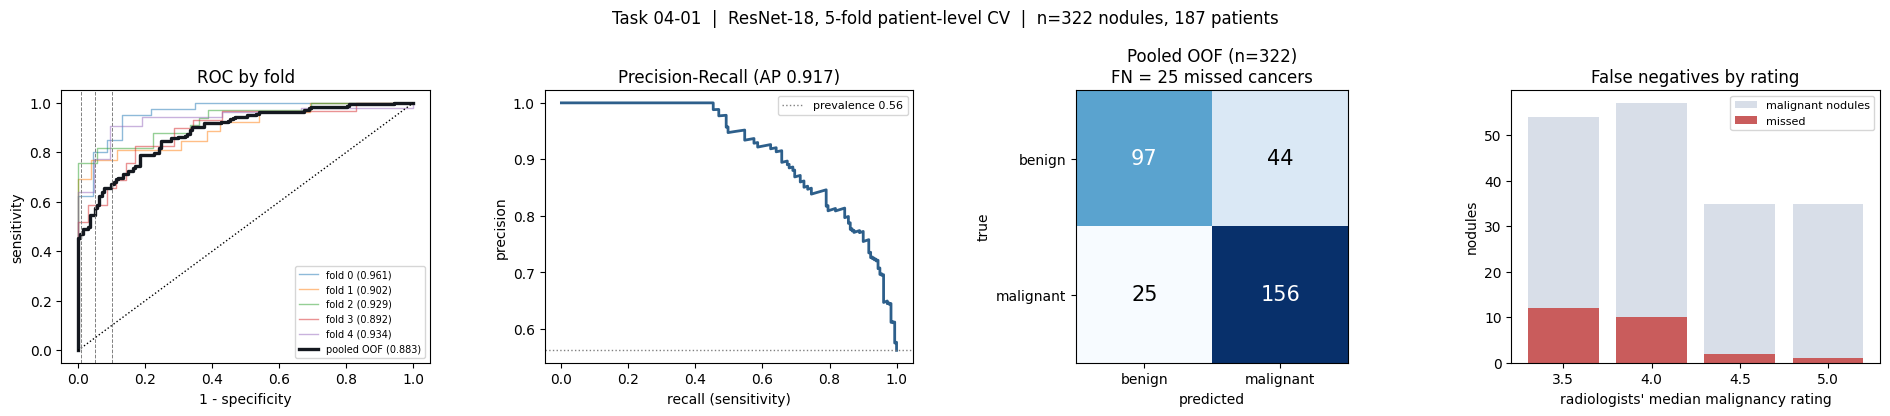

In [23]:
fig, ax = plt.subplots(1, 4, figsize=(19, 4.2))

for f in FOLDS:
    j = f["test"]
    fpr, tpr, _ = roc_curve(LABELS[j], OOF_P[j])
    ax[0].plot(fpr, tpr, lw=1.0, alpha=.5,
               label=f"fold {f['fold']} ({roc_auc_score(LABELS[j], OOF_P[j]):.3f})")
fpr, tpr, _ = roc_curve(LABELS, OOF_P)
ax[0].plot(fpr, tpr, lw=2.4, color="#14181f", label=f"pooled OOF ({POOLED['auroc']:.3f})")
ax[0].plot([0, 1], [0, 1], "k:", lw=1)
for ts in CFG["TARGET_SPECIFICITIES"]:
    ax[0].axvline(1 - ts, color="grey", ls="--", lw=.7)
ax[0].set_xlabel("1 - specificity"); ax[0].set_ylabel("sensitivity")
ax[0].set_title("ROC by fold"); ax[0].legend(fontsize=7, loc="lower right")

pr, rc, _ = precision_recall_curve(LABELS, OOF_P)
ax[1].plot(rc, pr, lw=2, color="#2d5f8b")
ax[1].axhline(LABELS.mean(), ls=":", color="grey", lw=1,
              label=f"prevalence {LABELS.mean():.2f}")
ax[1].set_xlabel("recall (sensitivity)"); ax[1].set_ylabel("precision")
ax[1].set_title(f"Precision-Recall (AP {POOLED['auprc']:.3f})"); ax[1].legend(fontsize=8)

cm = confusion_matrix(LABELS, (OOF_P >= .5).astype(int), labels=[0, 1])
ax[2].imshow(cm, cmap="Blues")
for i in range(2):
    for k in range(2):
        ax[2].text(k, i, cm[i, k], ha="center", va="center", fontsize=15,
                   color="white" if cm[i, k] > cm.max() / 2 else "black")
ax[2].set_xticks([0, 1], CLASS_NAMES); ax[2].set_yticks([0, 1], CLASS_NAMES)
ax[2].set_xlabel("predicted"); ax[2].set_ylabel("true")
ax[2].set_title(f"Pooled OOF (n={len(LABELS)})\nFN = {cm[1,0]} missed cancers")

ratings = sorted(set(np.round(MALIGNANCY[LABELS == 1].astype(float), 1)))
missed = [int((fn_mask & (np.round(MALIGNANCY.astype(float), 1) == v)).sum()) for v in ratings]
total = [int(((LABELS == 1) & (np.round(MALIGNANCY.astype(float), 1) == v)).sum())
         for v in ratings]
xs = np.arange(len(ratings))
ax[3].bar(xs, total, color="#d8dee8", label="malignant nodules")
ax[3].bar(xs, missed, color="#c95c5c", label="missed")
ax[3].set_xticks(xs, [str(v) for v in ratings])
ax[3].set_xlabel("radiologists' median malignancy rating"); ax[3].set_ylabel("nodules")
ax[3].set_title("False negatives by rating"); ax[3].legend(fontsize=8)

fig.suptitle(f"Task 04-01  |  ResNet-18, {CFG['N_FOLDS']}-fold patient-level CV  |  "
             f"n={len(LABELS)} nodules, {len(np.unique(PATIENT_ID))} patients"
             + ("   [SMOKE - NOT REPORTABLE]" if IS_SMOKE else ""), fontsize=12)
plt.tight_layout()
plt.savefig(f"{CFG['OUT_DIR']}/task04_01_results.png", dpi=120, bbox_inches="tight")
plt.show()

## 11 &nbsp;Outputs

Four files, plus the five fold checkpoints that Task 6 needs. The previous run wrote fifteen files
with heavily overlapping content, which made it unclear which was authoritative; everything here is
either the per-nodule predictions, the numbers computed from them, the audit record, or the figure.

**Save a Version before closing the session.** An interactive Kaggle session discards
`/kaggle/working` when it ends - that is how the previous run's checkpoints were lost.

In [24]:
OUT, M = CFG["OUT_DIR"], CFG["MODEL"]

# 1. per-nodule out-of-fold predictions - the input to any later paired comparison
np.savez_compressed(f"{OUT}/task04_01_oof_predictions.npz",
                    p=OOF_P, y=LABELS, cache_index=np.arange(len(LABELS)),
                    patient_id=PATIENT_ID.astype(object), fold=FOLD_OF,
                    malignancy=MALIGNANCY, model=M, fingerprint=FINGERPRINT,
                    build_version=CACHE_BUILD)

# 2. every number reported above, machine-readable
SUMMARY = dict(
    task="Task 04-01 - ResNet-18 baseline, patient-level 5-fold CV",
    model=M, build_version=CACHE_BUILD, fingerprint=FINGERPRINT, smoke=bool(IS_SMOKE),
    n_nodules=int(len(LABELS)), n_patients=int(len(np.unique(PATIENT_ID))),
    class_balance=dict(benign=int((LABELS == 0).sum()), malignant=int((LABELS == 1).sum())),
    protocol={k: CFG[k] for k in PROTOCOL_KEYS},
    hyperparameters={k: CFG[k] for k in ["EPOCHS", "BATCH_SIZE", "LR", "WEIGHT_DECAY",
                                         "DROPOUT_P", "DROPOUT_MODE", "PATIENCE"]},
    hyperparameter_search="none - all values fixed a priori (audit A5)",
    pooled_oof={k: v for k, v in POOLED.items() if isinstance(v, (int, float, bool, str))},
    per_fold=FOLD_METRICS.to_dict("records"),
    fold_summary={c: dict(mean=float(FOLD_METRICS[c].mean()),
                          sd=float(FOLD_METRICS[c].std(ddof=1)))
                  for c in ["auroc", "auprc", "accuracy", "sensitivity", "specificity",
                            "f1", "ece", "brier"]},
    clinical_operating_point=dict(threshold=CLINICAL_THRESHOLD,
                                  selected_on="per-fold validation slices",
                                  target_sensitivity=CFG["TARGET_SENSITIVITY"],
                                  **{k: CLIN[k] for k in ["sensitivity", "specificity", "fn", "fp"]}),
    false_negatives=dict(
        n_missed=int(fn_mask.sum()), n_malignant=int((LABELS == 1).sum()),
        fnr=float(fn_mask.sum() / max((LABELS == 1).sum(), 1)),
        by_rating={str(v): dict(missed=int((fn_mask & (np.round(MALIGNANCY.astype(float), 1) == v)).sum()),
                                total=int(((LABELS == 1) & (np.round(MALIGNANCY.astype(float), 1) == v)).sum()))
                   for v in sorted(set(np.round(MALIGNANCY[LABELS == 1].astype(float), 1)))}),
    sensitivity_analysis=SENSITIVITY_TABLE.to_dict("records"),
    ci_clustering_audit=CI_AUDIT.to_dict("records"),
    checkpoints=[os.path.basename(c) for c in CKPTS],
    environment=dict(torch=torch.__version__,
                     gpu=torch.cuda.get_device_name(0) if torch.cuda.is_available() else None),
)
with open(f"{OUT}/task04_01_summary.json", "w") as fh:
    json.dump(SUMMARY, fh, indent=2, default=str)

# 3. the audit record, so the review questions can be answered from a file
AUDIT = pd.DataFrame([
    dict(audit="A1 fold separation", question="Were patient-level folds genuinely separated?",
         evidence=f"0 patient overlap in all {CFG['N_FOLDS']} folds x 3 split pairs; "
                  f"0 patients split across test folds; test folds partition n={len(LABELS)} exactly",
         verdict="PASS"),
    dict(audit="A2 preprocessing", question="Was preprocessing fitted only on training folds?",
         evidence="No transform is fitted on data. Normalisation uses ImageNet constants; "
                  "crop size uses per-scan DICOM spacing; only the sampler weights are "
                  "fold-dependent and are asserted to derive from fold['train'] alone",
         verdict="PASS"),
    dict(audit="A3 patch geometry", question="How was the patch extracted; is 2.5D centred consistently?",
         evidence=f"In-plane {CFG['PATCH_MM']}mm constant across scans; through-plane neighbours at "
                  f"+/-{CFG['SLICE_MM']}mm with achieved offsets recorded per nodule "
                  f"({'measured' if HAS_GEOMETRY else 'NOT AVAILABLE in this cache'})",
         verdict="FIXED" if CACHE_BUILD == BUILD_VERSION else "OLD CACHE - defect present"),
    dict(audit="A4 labels", question="How were malignancy labels constructed?",
         evidence=f">={CFG['MIN_READERS']} readers, median fused, median==3 excluded; "
                  f"funnel and per-rating counts printed; n={len(LABELS)} stated everywhere",
         verdict="PASS"),
    dict(audit="A5 model selection", question="Did selection use test/OOF predictions?",
         evidence="Epoch selected on per-fold validation AUROC; training function takes no test "
                  "loader (asserted); no hyperparameter search was run; threshold chosen on validation",
         verdict="PASS"),
    dict(audit="A6 confidence intervals", question="Do CIs account for patient clustering?",
         evidence=f"Patient-level cluster bootstrap; intervals are "
                  f"{CI_AUDIT.width_ratio.mean():.2f}x the naive nodule-level width",
         verdict="PASS"),
])
AUDIT.to_csv(f"{OUT}/task04_01_audit.csv", index=False)

print("OUTPUTS")
for p in sorted(glob.glob(f"{OUT}/*")):
    print(f"  {os.path.getsize(p)/1024:9.1f} KB  {os.path.basename(p)}")

print(f"\n{'='*74}")
print(f"TASK 04-01  |  n = {len(LABELS)} nodules, {len(np.unique(PATIENT_ID))} patients"
      + ("   [SMOKE - NOT REPORTABLE]" if IS_SMOKE else ""))
print("="*74)
print(f"  AUROC        {POOLED['auroc']:.4f}  [{POOLED['auroc_ci_low']:.4f}, "
      f"{POOLED['auroc_ci_high']:.4f}]   (per-fold {POOLED['auroc_fold_mean']:.4f} "
      f"+/- {POOLED['auroc_fold_sd']:.4f})")
print(f"  Accuracy     {POOLED['accuracy']:.4f}")
print(f"  Sensitivity  {POOLED['sensitivity']:.4f}   Specificity {POOLED['specificity']:.4f}")
print(f"  Sens @ spec 0.90 / 0.95 : {POOLED['sens_at_spec_90']:.4f} / "
      f"{POOLED['sens_at_spec_95']:.4f}")
print(f"  False negatives {POOLED['fn']} of {int((LABELS==1).sum())} malignant "
      f"(FNR {100*POOLED['fnr']:.1f}%)")
print(f"\n  AUDITS: " + "  ".join(f"{r.audit.split()[0]}={r.verdict}"
                                  for r in AUDIT.itertuples()))
print(f"  fingerprint {FINGERPRINT}  |  cache build {CACHE_BUILD}")
print(f"\n  Reminder: Save Version, then publish the .npz cache and the checkpoints as a")
print(f"  Kaggle Dataset. Task 6 needs {len(CKPTS)} checkpoint files.")
print("="*74)

OUTPUTS
    43742.6 KB  resnet18_fold0_best.pt
    43742.6 KB  resnet18_fold1_best.pt
    43742.6 KB  resnet18_fold2_best.pt
    43742.6 KB  resnet18_fold3_best.pt
    43742.6 KB  resnet18_fold4_best.pt
        1.2 KB  task04_01_audit.csv
        4.9 KB  task04_01_oof_predictions.npz
      110.3 KB  task04_01_results.png
        8.9 KB  task04_01_summary.json

TASK 04-01  |  n = 322 nodules, 187 patients
  AUROC        0.8833  [0.8453, 0.9190]   (per-fold 0.9237 +/- 0.0274)
  Accuracy     0.7857
  Sensitivity  0.8619   Specificity 0.6879
  Sens @ spec 0.90 / 0.95 : 0.6740 / 0.5746
  False negatives 25 of 181 malignant (FNR 13.8%)

  AUDITS: A1=PASS  A2=PASS  A3=FIXED  A4=PASS  A5=PASS  A6=PASS
  fingerprint 5922c68330c537b8  |  cache build 2.0-mm-throughplane

  Reminder: Save Version, then publish the .npz cache and the checkpoints as a
  Kaggle Dataset. Task 6 needs 5 checkpoint files.


---

## 12 &nbsp;Packaging the outputs for download

Kaggle's Output panel downloads one file at a time, which is tedious for a run that produces four
result files plus five checkpoints. This cell writes **two** archives, because they are wanted for
different purposes and differ in size by three orders of magnitude.

| Archive | Contents | Size | Use |
|---|---|---|---|
| `<prefix>_results.zip` | the 4 result files only | ~hundreds of KB | **send this** for the comparison table |
| `<prefix>_full.zip` | results + checkpoints + the cache | ~250 MB | local archive / backup |

Checkpoints, `.npz` and `.png` files are already-compressed containers - a `.pt` is itself a zip -
so they are **stored** rather than deflated. Deflating them again costs minutes of CPU and saves
almost nothing.

> **For Task 6, do not download and re-upload.** Save a Version, then in the Task 6 notebook use
> `Add Input -> Your Work -> Notebook Output` and pick this run. That attaches the checkpoints
> directly, with no 250 MB round trip through your laptop. The `full` archive is for keeping a copy,
> not for moving data between notebooks.

In [25]:
import zipfile
from IPython.display import FileLink, display

# Already-compressed formats: storing them is ~10x faster and within a few percent of the same size
STORED_EXT = {".pt", ".pth", ".npz", ".npy", ".png", ".jpg", ".jpeg", ".zip", ".gz"}

def make_download_zip(zip_path, files, label):
    """Bundle `files` (list of absolute paths) into zip_path, then report and link it."""
    written, skipped = 0, []
    with zipfile.ZipFile(zip_path, "w", allowZip64=True) as z:
        for src in files:
            if not os.path.exists(src):
                skipped.append(os.path.basename(src)); continue
            ext = os.path.splitext(src)[1].lower()
            z.write(src, os.path.basename(src),
                    compress_type=zipfile.ZIP_STORED if ext in STORED_EXT
                    else zipfile.ZIP_DEFLATED)
            written += 1

    mb = os.path.getsize(zip_path) / 1e6
    print(f"{label}")
    print(f"  {os.path.basename(zip_path)}  |  {written} files  |  {mb:.1f} MB")
    if skipped:
        print(f"  not found, skipped: {skipped}")
    # FileLink only resolves for a path under the notebook's working directory, so fall back to
    # printing the path anywhere else rather than rendering a broken link.
    try:
        rel = os.path.relpath(zip_path, "/kaggle/working")
        if rel.startswith("..") or os.path.isabs(rel):
            raise ValueError("outside /kaggle/working")
        display(FileLink(rel))
    except Exception:
        print(f"  path: {zip_path}")
    return zip_path


# "task04_01" or "task05_01", taken from the output directory so this cell is model-agnostic
PREFIX = os.path.basename(CFG["OUT_DIR"]).replace("_outputs", "")
RESULT_FILES = sorted(p for p in glob.glob(f"{CFG['OUT_DIR']}/*")
                      if not p.endswith("_best.pt") and not p.endswith(".zip"))
CKPT_FILES = sorted(glob.glob(f"{CFG['OUT_DIR']}/*_best.pt"))
CACHE_FILE = [CACHE] if os.path.exists(CACHE) else []

print("=" * 74)
make_download_zip(f"{CFG['WORK']}/{PREFIX}_results.zip", RESULT_FILES,
                  "SMALL - the files needed for the comparison table:")
print()
make_download_zip(f"{CFG['WORK']}/{PREFIX}_full.zip",
                  RESULT_FILES + CKPT_FILES + CACHE_FILE,
                  "FULL - everything, for a local archive:")
print("=" * 74)
print(f"  {len(CKPT_FILES)} checkpoints and the cache are in the full archive only.")
print(f"  Both appear in the Output panel after the cell finishes; refresh it if not.")
print(f"  For Task 6, attach this run's Notebook Output instead of downloading.")

SMALL - the files needed for the comparison table:
  task04_01_results.zip  |  4 files  |  0.1 MB


/kaggle/working/task04_01_results.zip


FULL - everything, for a local archive:
  task04_01_full.zip  |  10 files  |  250.3 MB


/kaggle/working/task04_01_full.zip

  5 checkpoints and the cache are in the full archive only.
  Both appear in the Output panel after the cell finishes; refresh it if not.
  For Task 6, attach this run's Notebook Output instead of downloading.


In [26]:
!cd /kaggle/working && zip -r task04_outputs.zip task04_01_outputs

  adding: task04_01_outputs/ (stored 0%)
  adding: task04_01_outputs/task04_01_summary.json (deflated 70%)
  adding: task04_01_outputs/resnet18_fold0_best.pt (deflated 7%)
  adding: task04_01_outputs/resnet18_fold2_best.pt (deflated 7%)
  adding: task04_01_outputs/resnet18_fold3_best.pt (deflated 7%)
  adding: task04_01_outputs/resnet18_fold1_best.pt (deflated 7%)
  adding: task04_01_outputs/task04_01_audit.csv (deflated 44%)
  adding: task04_01_outputs/resnet18_fold4_best.pt (deflated 7%)
  adding: task04_01_outputs/task04_01_oof_predictions.npz (deflated 15%)
  adding: task04_01_outputs/task04_01_results.png (deflated 14%)
